<a href="https://colab.research.google.com/github/MomenJabr/Metabolic-Syndrome-Prediction/blob/main/Metabolic_Syndrome_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metabolic Syndrome Prediction

## The dataset for analysis came from the NHANES initiative where the following variables were combined from multiple tables with SQL: abnormal waist circumference, triglycerides above 150, HDL cholesterol below 50 in women or 40 in men, history of hypertension and mildly elevated fasting blood sugar (100-125). Numerous other variables were added, such as uric acid, race, income, etc. that might contribute to the model but we will not sure, until we test the model.

## In this project, particular attention is given to the recall metric when evaluating the performance of the machine learning models. Recall measures the model’s ability to correctly identify positive cases, which in this study correspond to individuals who have metabolic syndrome. In medical prediction tasks, minimizing false negatives is especially important because failing to identify a patient who actually has the condition may delay diagnosis and treatment. Therefore, achieving a high recall ensures that the model is able to detect as many true cases as possible. For this reason, recall is considered a key evaluation metric in this study, while other metrics such as precision, F1-score, and accuracy are also reported to provide a comprehensive evaluation of model performance.

### Importing some packages at the beginning

In [1]:
# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Advanced
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
# show all columns
pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

from sklearn import set_config
set_config(transform_output="pandas")


In [2]:
# import the dataset
df = pd.read_csv('https://query.data.world/s/mq6fh4qiajksnyq5g2zo3nyls36jx3?dws=00000')
df.head()

,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
0,62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,No MetSyn
1,62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,No MetSyn
2,62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,No MetSyn
3,62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,No MetSyn
4,62177,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,No MetSyn


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2401 entries, 0 to 2400
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   seqn               2401 non-null   int64  
 1   Age                2401 non-null   int64  
 2   Sex                2401 non-null   object 
 3   Marital            2193 non-null   object 
 4   Income             2284 non-null   float64
 5   Race               2401 non-null   object 
 6   WaistCirc          2316 non-null   float64
 7   BMI                2375 non-null   float64
 8   Albuminuria        2401 non-null   int64  
 9   UrAlbCr            2401 non-null   float64
 10  UricAcid           2401 non-null   float64
 11  BloodGlucose       2401 non-null   int64  
 12  HDL                2401 non-null   int64  
 13  Triglycerides      2401 non-null   int64  
 14  MetabolicSyndrome  2401 non-null   object 
dtypes: float64(5), int64(6), object(4)
memory usage: 281.5+ KB


In [4]:
# make seqn as index
df.set_index('seqn', inplace=True)

In [5]:
# check for nun values
df.isna().sum()

,0
Age,0
Sex,0
Marital,208
Income,117
Race,0
WaistCirc,85
BMI,26
Albuminuria,0
UrAlbCr,0
UricAcid,0


In [6]:
# check for duplication
df.duplicated().sum()

np.int64(0)

In [7]:
# check for data type
df.dtypes

,0
Age,int64
Sex,object
Marital,object
Income,float64
Race,object
WaistCirc,float64
BMI,float64
Albuminuria,int64
UrAlbCr,float64
UricAcid,float64


<Axes: >

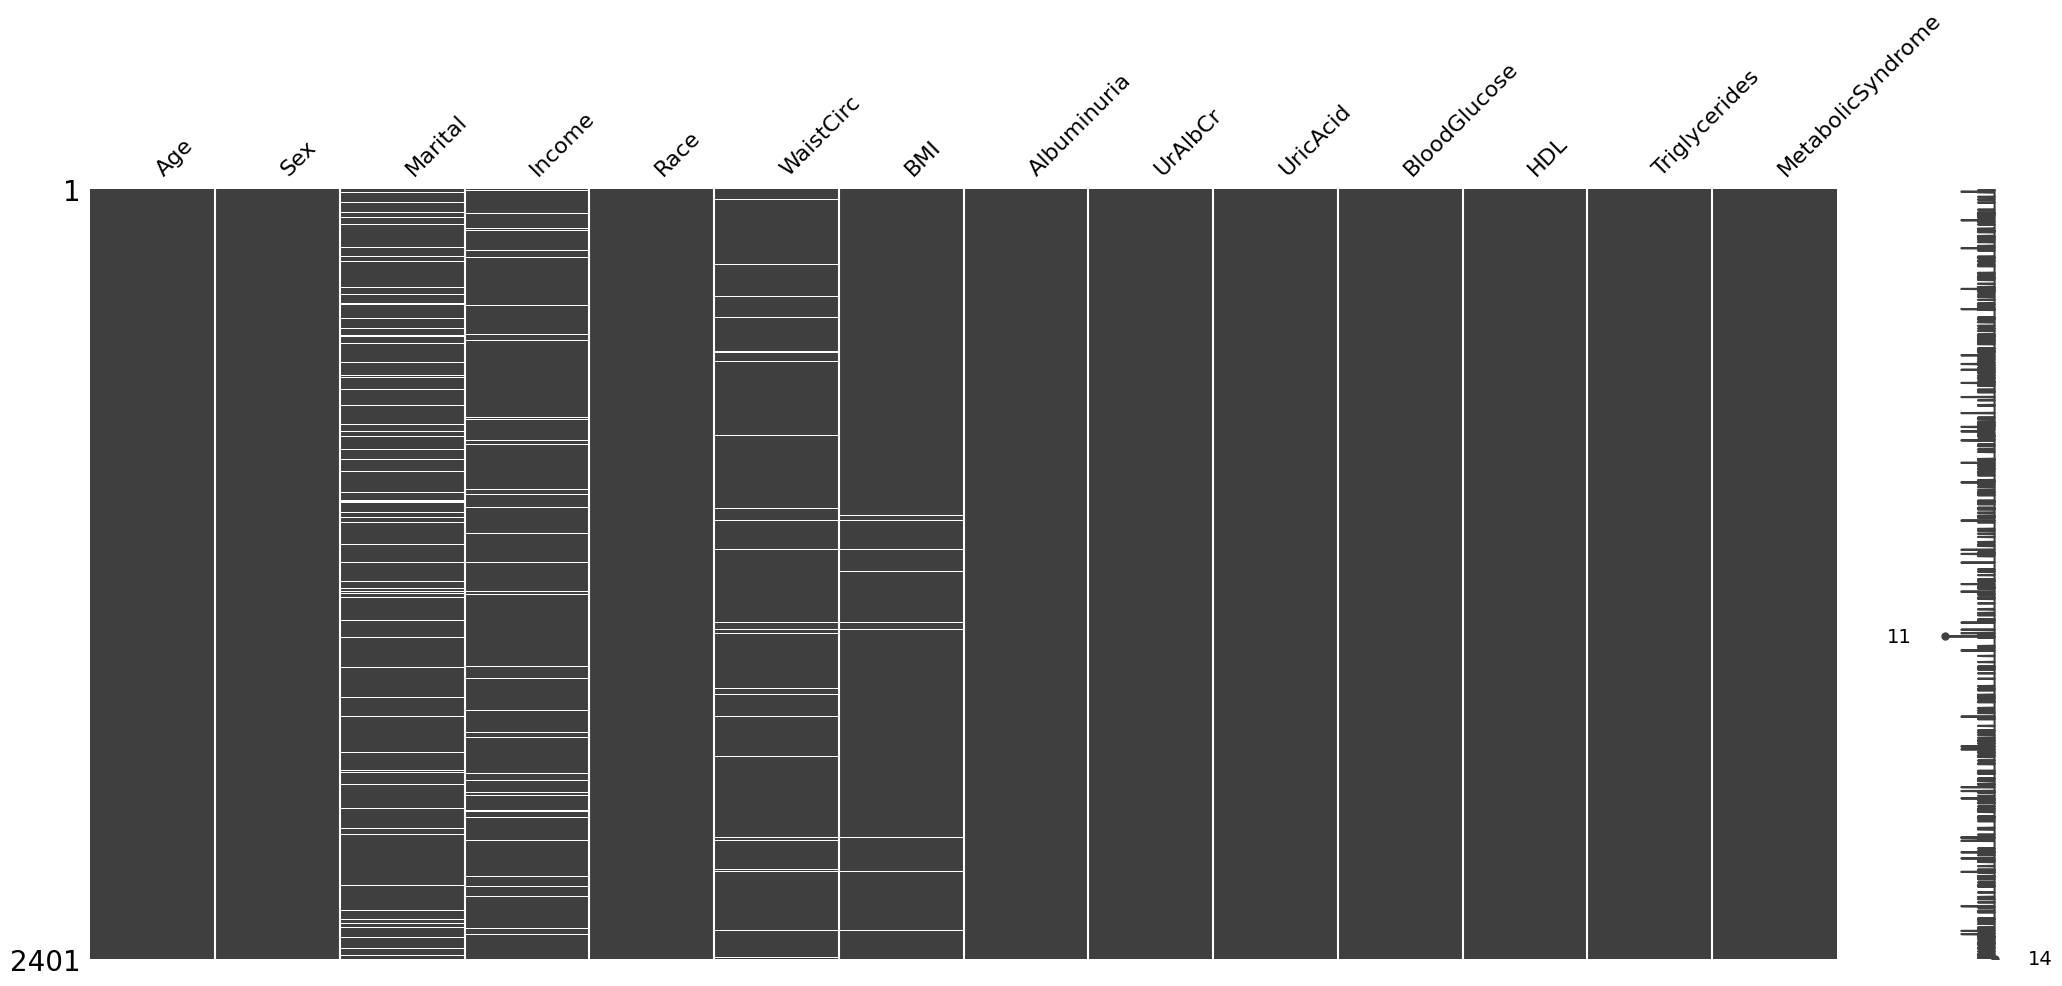

In [8]:
# showing missing values
import missingno as msno
msno.matrix(df)

In [9]:
df.describe()

,Age,Income,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides
count,2401.000000,2284.000000,2316.000000,2375.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000
mean,48.691795,4005.253940,98.307254,28.702189,0.154102,43.626131,5.489046,108.247813,53.369429,128.125364
std,17.632852,2954.032186,16.252634,6.662242,0.422780,258.272829,1.439358,34.820657,15.185537,95.322477
min,20.000000,300.000000,56.200000,13.400000,0.000000,1.400000,1.800000,39.000000,14.000000,26.000000
25%,34.000000,1600.000000,86.675000,24.000000,0.000000,4.450000,4.500000,92.000000,43.000000,75.000000
50%,48.000000,2500.000000,97.000000,27.700000,0.000000,7.070000,5.400000,99.000000,51.000000,103.000000
75%,63.000000,6200.000000,107.625000,32.100000,0.000000,13.690000,6.400000,110.000000,62.000000,150.000000
max,80.000000,9000.000000,176.000000,68.700000,2.000000,5928.000000,11.300000,382.000000,156.000000,1562.000000


In [10]:
# for categoral values
df.select_dtypes('object').describe()

,Sex,Marital,Race,MetabolicSyndrome
count,2401,2193,2401,2401
unique,2,5,6,2
top,Female,Married,White,No MetSyn
freq,1211,1192,933,1579


In [11]:
for i in df.select_dtypes('object'):
    print(df[i].value_counts())


Sex
Female    1211
Male      1190
Name: count, dtype: int64
Marital
Married      1192
Single        498
Divorced      242
Widowed       166
Separated      95
Name: count, dtype: int64
Race
White          933
Black          548
Asian          349
Hispanic       257
MexAmerican    253
Other           61
Name: count, dtype: int64
MetabolicSyndrome
No MetSyn    1579
MetSyn        822
Name: count, dtype: int64


According to the previous data exploration, there isnt any inconsistency or extreme illogical values

In [12]:
for i in df.select_dtypes(exclude='object'):
    print(f'unique value of {df[i].name} is : \n {df[i].nunique()}\n')

unique value of Age is : 
 61

unique value of Income is : 
 14

unique value of WaistCirc is : 
 635

unique value of BMI is : 
 322

unique value of Albuminuria is : 
 3

unique value of UrAlbCr is : 
 1383

unique value of UricAcid is : 
 88

unique value of BloodGlucose is : 
 187

unique value of HDL is : 
 93

unique value of Triglycerides is : 
 345



In [13]:
df['Albuminuria'].unique()

array([0, 1, 2])

as we can see that Albuminuria is an ordinal value

to explore if the values are constant or quise constant:

In [14]:

results = []

for col in df.columns:
    value_ratios = df[col].value_counts(normalize=True, dropna=False)

    top_ratio = value_ratios.iloc[0]


    top_value = value_ratios.index[0]


    if top_ratio == 1.0:
        feature_type = 'constant'
    elif top_ratio >= 0.98:
        feature_type = 'quasi-constant (>=98%)'
    elif top_ratio >= 0.95:
        feature_type = 'quasi-constant (>=95%)'
    elif top_ratio >= 0.90:
        feature_type = 'quasi-constant (>=90%)'
    else:
        feature_type = 'not constant'

    results.append({
        'feature': col,
        'most_frequent_value': top_value,
        'top_frequency_ratio': top_ratio,
        'top_frequency_percent': round(top_ratio * 100, 2),
        'status': feature_type
    })

constant_df = pd.DataFrame(results).sort_values(by='top_frequency_ratio', ascending=False)

print(constant_df)

              feature most_frequent_value  top_frequency_ratio  \
7         Albuminuria                   0             0.870054   
13  MetabolicSyndrome           No MetSyn             0.657643   
1                 Sex              Female             0.504373   
2             Marital             Married             0.496460   
4                Race               White             0.388588   
3              Income              9000.0             0.140358   
0                 Age                  80             0.051645   
10       BloodGlucose                  97             0.037484   
11                HDL                  48             0.036235   
5           WaistCirc                 NaN             0.035402   
9            UricAcid                 5.2             0.032070   
12      Triglycerides                  75             0.014161   
6                 BMI                 NaN             0.010829   
8             UrAlbCr                 5.0             0.007497   

    top_f

## Creating exploratory visualizations to understand your data and search for trends.

In [15]:
def explore_numeric(df, x, figsize=(6,5) ):
  # Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])
  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])
  ## Adding a title
  axes[0].set_title(f"Column: {x}")
  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()
  ## Print message with info on the count and % of null values
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")

In [16]:
df.select_dtypes(exclude='object').columns

Index(['Age', 'Income', 'WaistCirc', 'BMI', 'Albuminuria', 'UrAlbCr',
       'UricAcid', 'BloodGlucose', 'HDL', 'Triglycerides'],
      dtype='object')

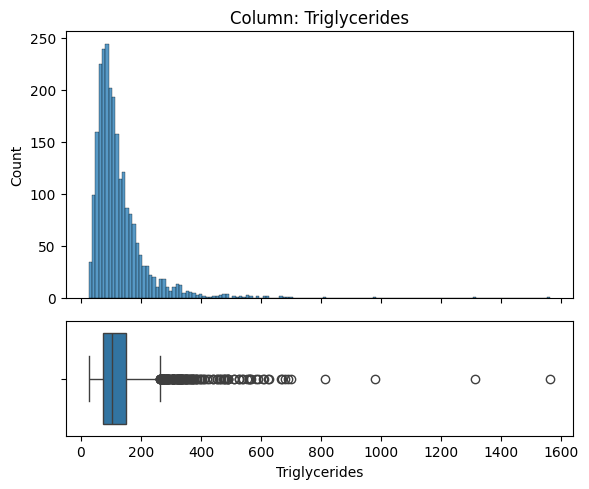

- NaN's Found: 0 (0.0%)


In [17]:
explore_numeric(df, 'Triglycerides')

Triglycerides exhibit a highly right-skewed distribution with numerous extreme values. These extreme values may represent clinically significant cases rather than noise, and therefore should be carefully handled rather than removed outright

lets explore a plot for this feature with the target

In [18]:
# Updating the function
def plot_numeric_vs_target(df, x, y, figsize=(6,4),
                           target_type='reg', estimator='mean',
                           errorbar='ci',sorted=False,ascending=False,
                           **kwargs): # kwargs for sns.regplot

  nulls = df[[x,y]].isna().sum()
  if nulls.sum()>0:
    print(f"- Excluding {nulls.sum()} NaN's")
    # print(nulls)
    temp_df = df.dropna(subset=[x,y,])
  else:
    temp_df = df
  # Create the figure
  fig, ax = plt.subplots(figsize=figsize)

  # REGRESSION-TARGET PLOT
  if 'reg' in target_type:
    # Calculate the correlation
    corr = df[[x,y]].corr().round(2)
    r = corr.loc[x,y]
    # Plot the data
    scatter_kws={'ec':'white','lw':1,'alpha':0.8}
    sns.regplot(data=temp_df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
    ## Add the title with the correlation
    ax.set_title(f"{x} vs. {y} (r = {r})")

  # CLASSIFICATION-TARGET PLOT
  elif 'class' in target_type:

    # Sort the groups by median/mean
    if sorted == True:

      if estimator == 'median':
        group_vals = temp_df.groupby(y)[x].median()
      elif estimator =='mean':
        group_vals = temp_df.groupby(y)[x].mean()

      ## Sort values
      group_vals = group_vals.sort_values(ascending=ascending)
      order = group_vals.index

    else:
      # Set order to None if not calcualted
      order = None


    # Left Subplot (barplot)
    sns.barplot(data=temp_df, x=y, y=x, order=order,  estimator=estimator,
                errorbar=errorbar, ax=ax, **kwargs)

    # Add title
    ax.set_title(f"{x} vs. {y}")

    # rotate xaxis labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


  # Final Adjustments & return
  fig.tight_layout()
  fig.show()
  return fig, ax

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Triglycerides vs. MetabolicSyndrome'}, xlabel='MetabolicSyndrome', ylabel='Triglycerides'>)

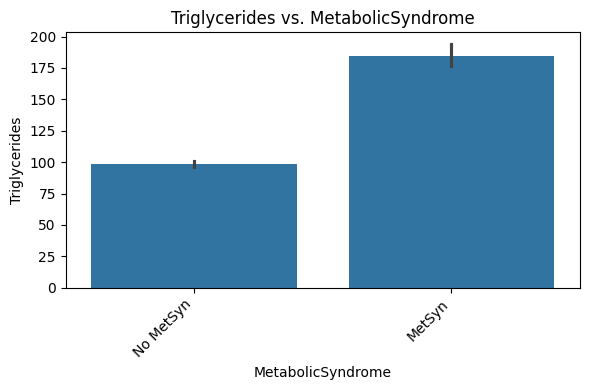

In [19]:
# lets explore a plot for this feature with the target
plot_numeric_vs_target(df, 'Triglycerides','MetabolicSyndrome', target_type='class')

 its obvious that people with Metsyn has larger values of Triglycerides

###  we will explore all numerical feature with the target

- Excluding 117 NaN's
- Excluding 85 NaN's
- Excluding 26 NaN's


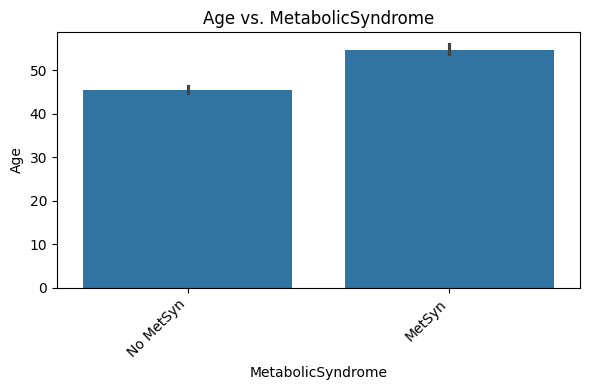

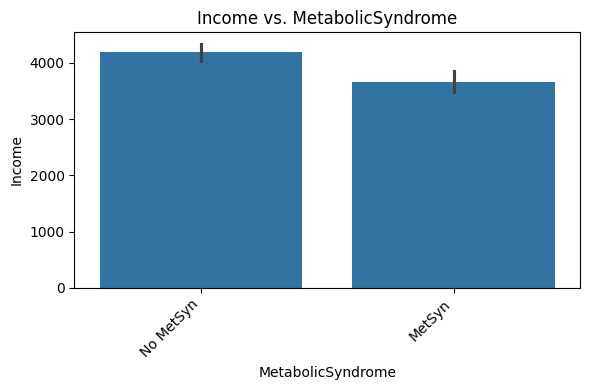

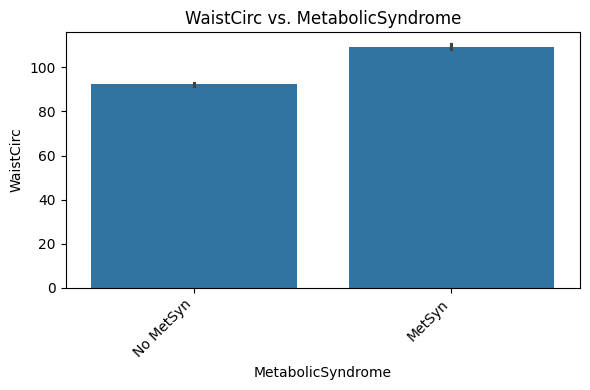

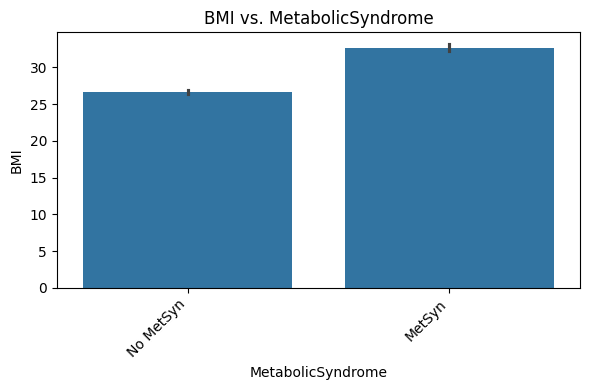

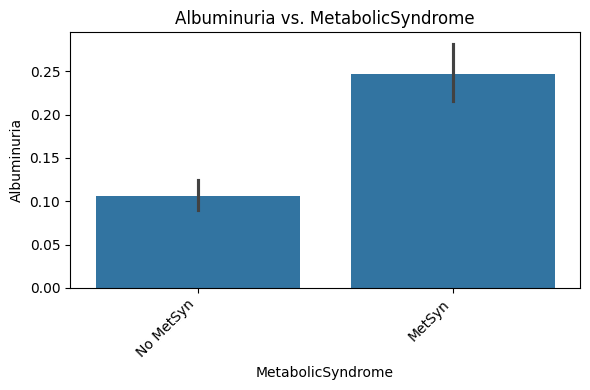

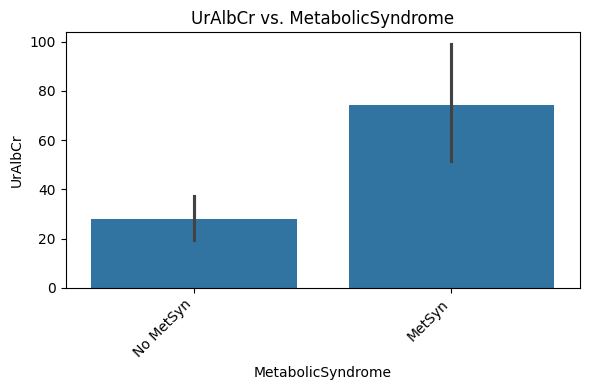

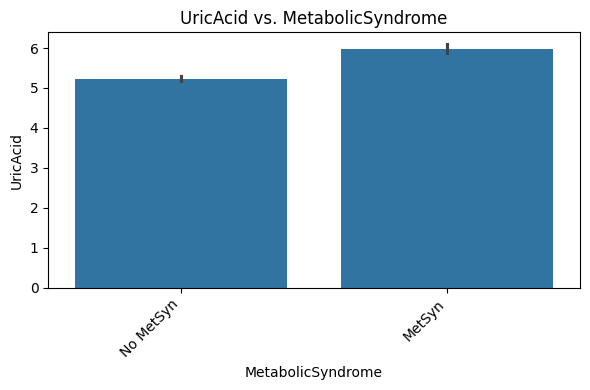

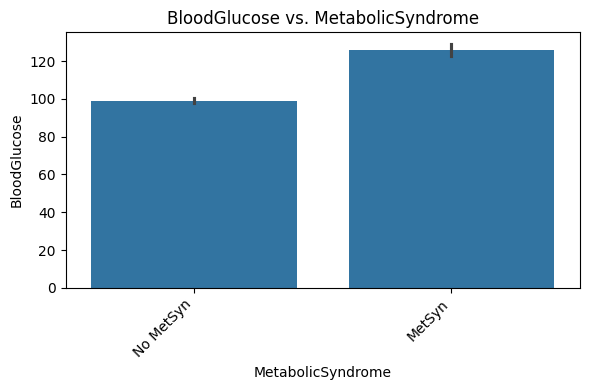

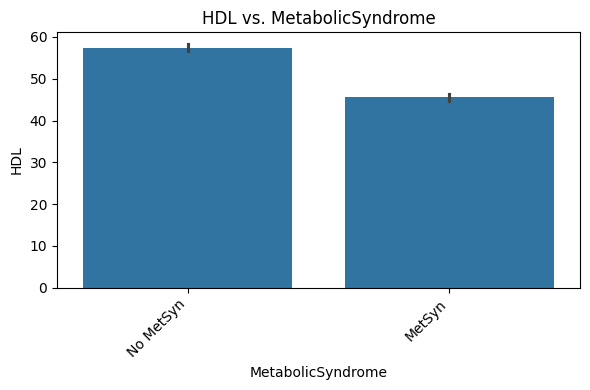

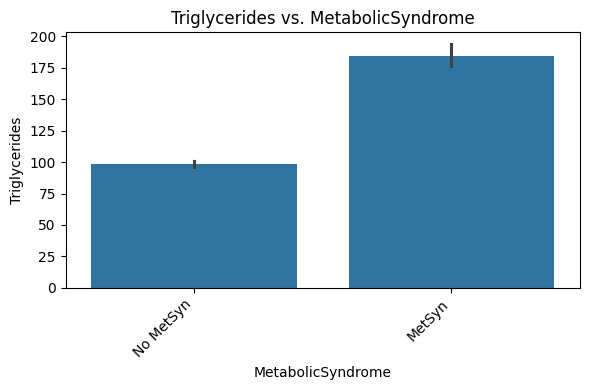

In [20]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

target = 'MetabolicSyndrome'
if target in numeric_cols:
    numeric_cols.remove(target)

for feature in numeric_cols:
    plot_numeric_vs_target(df, feature, target, target_type='class')

based on the visualizations, in adition of Triglycerides,  Albuminuria and UrAlbCr appear to be among the features most strongly associated with Metabolic Syndrome.
In both plots, individuals diagnosed with Metabolic Syndrome show noticeably higher average values compared to those without the condition.
This clear separation between the two groups suggests that increased levels of Albuminuria and UrAlbCr may be important indicators related to the presence of Metabolic Syndrome and could potentially contribute to identifying or predicting the condition.

Also, we will explore correlation between features:

In [21]:
# correlation
corr = df.select_dtypes(exclude='object').corr()
corr

,Age,Income,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides
Age,1.000000,-0.011982,0.226470,0.079916,0.233464,0.118380,0.147928,0.236610,0.079368,0.069885
Income,-0.011982,1.000000,-0.063519,-0.081061,-0.100098,-0.048996,0.007967,-0.093311,0.077549,-0.039772
WaistCirc,0.226470,-0.063519,1.000000,0.908751,0.121825,0.047630,0.355836,0.261579,-0.352481,0.236098
BMI,0.079916,-0.081061,0.908751,1.000000,0.077088,0.038740,0.272089,0.209645,-0.292905,0.163758
Albuminuria,0.233464,-0.100098,0.121825,0.077088,1.000000,0.536214,0.176760,0.198642,-0.024188,0.107842
UrAlbCr,0.118380,-0.048996,0.047630,0.038740,0.536214,1.000000,0.130928,0.106458,0.001667,0.077873
UricAcid,0.147928,0.007967,0.355836,0.272089,0.176760,0.130928,1.000000,0.055943,-0.252587,0.207328
BloodGlucose,0.236610,-0.093311,0.261579,0.209645,0.198642,0.106458,0.055943,1.000000,-0.213905,0.269506
HDL,0.079368,0.077549,-0.352481,-0.292905,-0.024188,0.001667,-0.252587,-0.213905,1.000000,-0.388487
Triglycerides,0.069885,-0.039772,0.236098,0.163758,0.107842,0.077873,0.207328,0.269506,-0.388487,1.000000


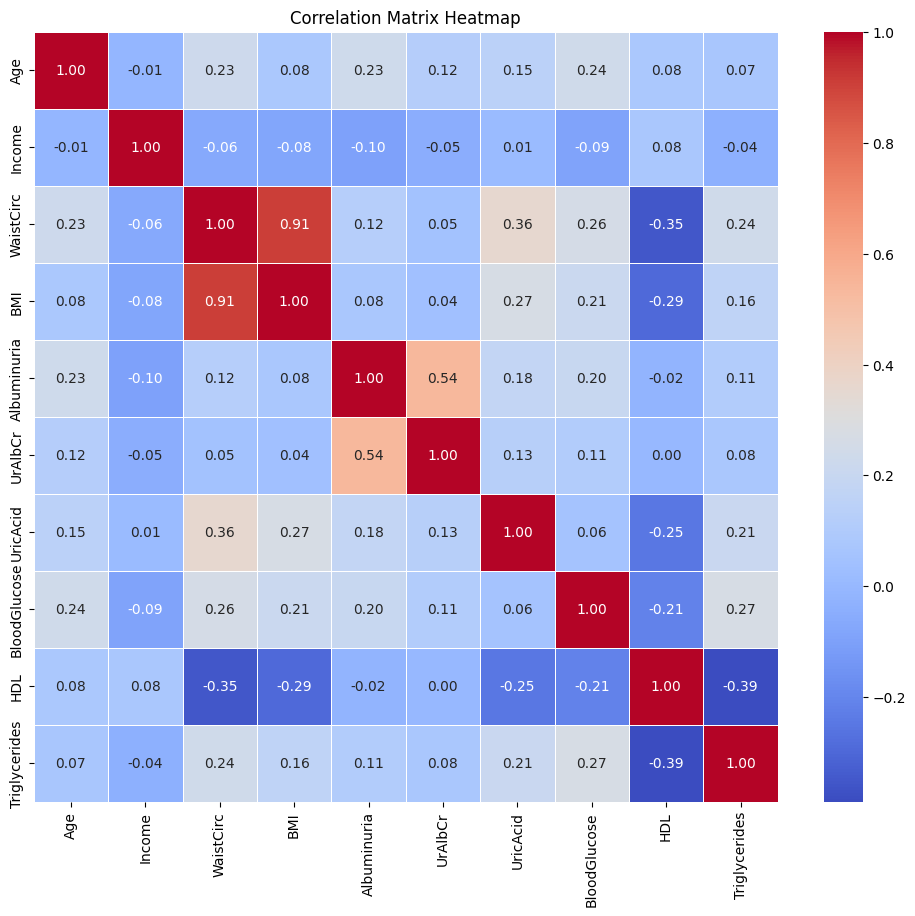

In [22]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
plt.show()

## we can see high correlation between BMI and WaistCirc, we will also use VIF to see Multicolinearity

resourse: https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer

X = df.select_dtypes(exclude='object').copy()

# Impute missing values for VIF calculation
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

vif = pd.DataFrame()
vif["feature"] = X_imputed.columns
vif["VIF"] = [variance_inflation_factor(X_imputed.values, i) for i in range(X_imputed.shape[1])]

vif

,feature,VIF
0,Age,10.838790
1,Income,2.870636
2,WaistCirc,164.015115
3,BMI,91.822149
4,Albuminuria,1.698341
5,UrAlbCr,1.453902
6,UricAcid,17.688224
7,BloodGlucose,12.076670
8,HDL,10.015148
9,Triglycerides,3.491387


### its recomended to delete one of those two feature, after googling the effects of both two features on the metabolic syndrome, it seems that Waist circumference is more importance indicator for heart diseases

source: https://www.who.int/publications/i/item/9789241501491

page 19: However, alternative measures
that reflect abdominal adiposity, such as waist circumference, waist–hip ratio and waist–
height ratio, have been suggested as being superior to BMI in predicting CVD ris

Since there is multicollinearity between BMI and WaistCirc, we will eventually remove one of them. However, before doing so, we will build a model and examine the feature importance of both variables to determine which feature contributes more to the prediction. This will help us make a more informed decision about which feature to remove.

In [24]:
#df = df.drop(columns='BMI')

### now exploring categorical data with target

In [25]:
# Updating function

import matplotlib.pyplot as plt
import seaborn as sns
def plot_categorical_vs_target(df, x, y, figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None, target_type='reg'):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)
  # REGRESSION-TARGET PLOT
  if target_type=='reg': #Added if statement here
    # Barplot
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
                linewidths=1, edgecolor='black', errorbar=None)
    # Boxplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                  order=order, hue_order=order, legend=False,
                  edgecolor='white', linewidth=0.5,
                  size=3,zorder=0)
  # CLASSIFICATION-TARGET PLOT # This is the new code for the classification task
  elif target_type=='class':
    ax = sns.histplot(data=temp_df, hue=y, x=x, stat='percent',  multiple='fill')
  # Rotate xlabels
  ax.set_xticks(ax.get_xticks()) # Added this to prevent a bug
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

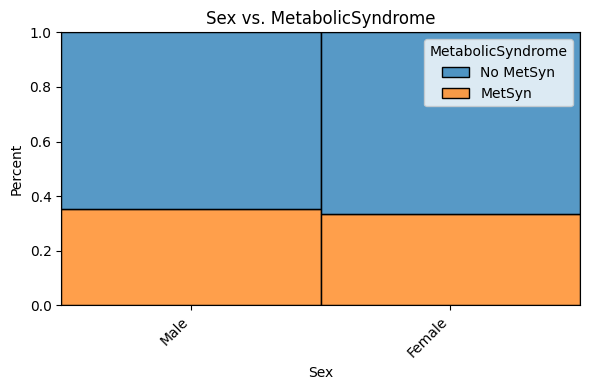

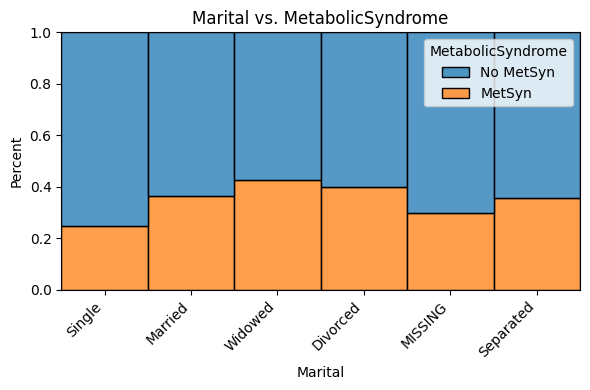

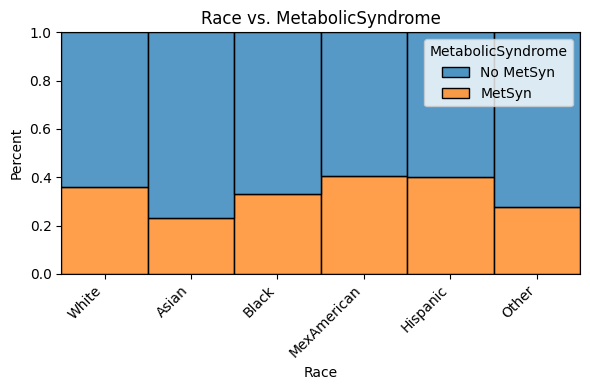

In [26]:
cat_cols = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

target = 'MetabolicSyndrome'
if target in cat_cols:
    cat_cols.remove(target)

for feature in cat_cols:
    plot_categorical_vs_target(df, feature, target, target_type='class')

Sex vs. Metabolic Syndrome:
The visualization shows that the proportion of individuals with Metabolic Syndrome is very similar between males and females. Both groups display nearly the same distribution of MetSyn and No MetSyn cases, suggesting that sex does not appear to have a strong association with Metabolic Syndrome in this dataset.

Marital Status vs. Metabolic Syndrome:
Some variation in the proportion of Metabolic Syndrome can be observed across marital status groups. Individuals who are widowed or divorced appear to show slightly higher proportions of MetSyn compared to single individuals. However, this pattern may be influenced by other factors such as age differences between marital status groups rather than marital status itself.

Race vs. Metabolic Syndrome:
The distribution of Metabolic Syndrome varies slightly across racial groups. Certain groups, such as Mexican American and Hispanic individuals, appear to have somewhat higher proportions of MetSyn compared to others, while groups like Asians show lower proportions. Nevertheless, these differences are relatively modest and do not indicate a strong separation between groups.

# Machine Learning Pipeline

### Preprocess data

In [27]:
df.head()

,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
seqn,,,,,,,,,,,,,,
62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,No MetSyn
62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,No MetSyn
62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,No MetSyn
62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,No MetSyn
62177,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,No MetSyn


In [28]:
X= df.drop(columns='MetabolicSyndrome')
y = df['MetabolicSyndrome']
# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### check for imbalance

In [29]:
y.value_counts(dropna=False)

,count
MetabolicSyndrome,
No MetSyn,1579
MetSyn,822


The dataset used in this study shows a moderate class imbalance, where approximately two-thirds of the samples belong to the non-metabolic syndrome class and one-third belong to the metabolic syndrome class. Although class imbalance can affect the performance of machine learning models, the imbalance in this dataset is not severe. Therefore, it is not strictly necessary to apply data balancing techniques such as oversampling or SMOTE. Instead, the study focuses on evaluation metrics such as recall to ensure that the models effectively identify individuals with metabolic syndrome. Additionally, model parameters and decision thresholds can be adjusted to improve recall without significantly altering the original data distribution.

In [30]:
## PREPROCESSING PIPELINE FOR NUMERIC DATA
# Save list of column names
num_cols = X_train.select_dtypes(include='number').columns.drop('Albuminuria')
print("Numeric Columns:", num_cols)
# instantiate preprocessors
impute_median = SimpleImputer(strategy='median')
scaler = StandardScaler()
# Make a numeric preprocessing pipeline
num_pipe = make_pipeline(impute_median, scaler)
# Making a numeric tuple for ColumnTransformer
#           (choose_a_name, pipeline_or_transformer, list_of_columns)
num_tuple = ('numeric', num_pipe, num_cols)

Numeric Columns: Index(['Age', 'Income', 'WaistCirc', 'BMI', 'UrAlbCr', 'UricAcid',
       'BloodGlucose', 'HDL', 'Triglycerides'],
      dtype='object')


In [31]:
ord_cols = ['Albuminuria']
print("Ordinal Columns:", ord_cols)

impute_ord = SimpleImputer(strategy='most_frequent')

ord_pipe = make_pipeline(impute_ord, StandardScaler())

ord_tuple = ('ordinal', ord_pipe, ord_cols)

Ordinal Columns: ['Albuminuria']


In [32]:
## PREPROCESSING PIPELINE FOR ONE-HOT-ENCODED DATA
# Save list of column names
ohe_cols = X_train.select_dtypes('object').columns
print("OneHotEncoder Columns:", ohe_cols)
# Instantiate the individual preprocessors
impute_na = SimpleImputer(strategy='constant', fill_value = "NA")
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Make pipeline with imputer and encoder
ohe_pipe = make_pipeline(impute_na, ohe_encoder)
# Making a ohe_tuple for ColumnTransformer
#           (choose_a_name, pipeline_or_transformer, list_of_columns)
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

OneHotEncoder Columns: Index(['Sex', 'Marital', 'Race'], dtype='object')


In [33]:
# Instantiate the preprocessor/ColumnTransformer
preprocessor = ColumnTransformer([num_tuple, ord_tuple,ohe_tuple],
                                 verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Age', 'Income', 'WaistCirc', 'BMI', 'UrAlbCr', 'UricAcid',
       'BloodGlucose', 'HDL', 'Triglycerides'],
      dtype='object')),
                                ('ordinal',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Albuminuria']),
                                ('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='NA',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Sex', 'Marital', 'Race'], dtype='object'))],
                  verbose_feature_names_out=False)

In [34]:
# Fit the preprocessor on training data
preprocessor.fit(X_train)
# Transform the training and test data
X_train_tf = preprocessor.transform(X_train)
X_test_tf = preprocessor.transform(X_test)
X_train_tf.head()

,Age,Income,WaistCirc,BMI,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,Albuminuria,Sex_Female,Sex_Male,Marital_Divorced,Marital_Married,Marital_NA,Marital_Separated,Marital_Single,Marital_Widowed,Race_Asian,Race_Black,Race_Hispanic,Race_MexAmerican,Race_Other,Race_White
seqn,,,,,,,,,,,,,,,,,,,,,,,,
63211,-0.176875,1.443579,1.591313,1.815754,-0.100646,-1.503810,0.962189,-0.045041,0.728110,-0.366397,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
70548,-0.857407,-0.165173,-0.767163,-0.637064,-0.108892,0.406271,0.185052,1.929154,-0.704544,-0.366397,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
64722,-0.914117,-0.165173,-1.465971,-0.561824,-0.125171,-1.435593,-0.323077,-0.637299,-0.704544,-0.366397,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
69237,-0.006742,1.717409,-0.174425,0.687157,-0.152526,-1.913113,-0.562196,-0.176654,0.115599,-0.366397,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
65286,-1.084250,1.717409,-1.422296,-1.028311,-0.138548,1.088443,-0.801315,0.283992,2.762893,-0.366397,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [35]:
# # using smote
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)

# X_train_smote, y_train_smote = smote.fit_resample(X_train_tf, y_train)

In [36]:
y_train = y_train.map({'No MetSyn': 0, 'MetSyn': 1})
y_test = y_test.map({'No MetSyn': 0, 'MetSyn': 1})

## establishing a model, we will use random forest for clasification target

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
rf_model = RandomForestClassifier()

In [39]:
rf_model.fit(X_train_tf, y_train)

RandomForestClassifier()

In [40]:
y_pred = rf_model.predict(X_test_tf)

In [41]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1182
           1       1.00      1.00      1.00       618

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



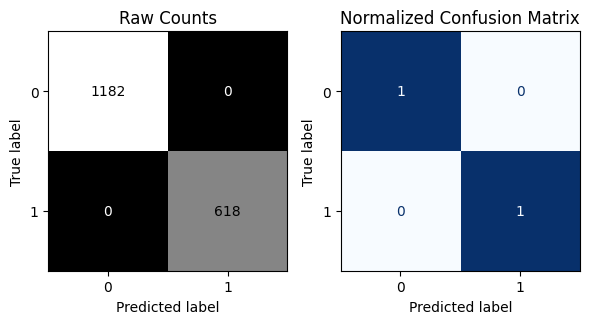


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       397
           1       0.82      0.77      0.79       204

    accuracy                           0.87       601
   macro avg       0.85      0.84      0.85       601
weighted avg       0.86      0.87      0.86       601



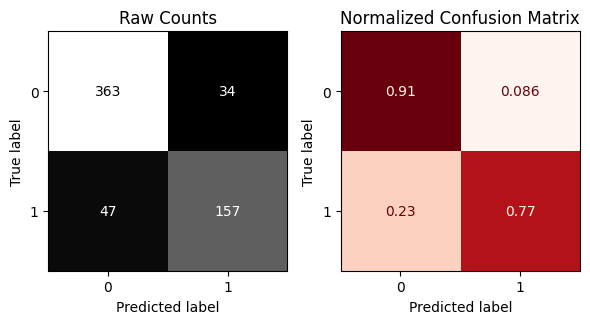

In [43]:
# evauate clasification
evaluate_classification(rf_model, X_train_tf, y_train, X_test_tf, y_test)

there is an obvious overfitting, so ill use gridsearch to tune hperparameters

In [44]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [45]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_tf, y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=2)

In [46]:
# Obtain the best combination directly
grid_search.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 100}

In [47]:
# Now define the best version of the model
best_model = grid_search.best_estimator_

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1182
           1       0.97      0.95      0.96       618

    accuracy                           0.97      1800
   macro avg       0.97      0.97      0.97      1800
weighted avg       0.97      0.97      0.97      1800



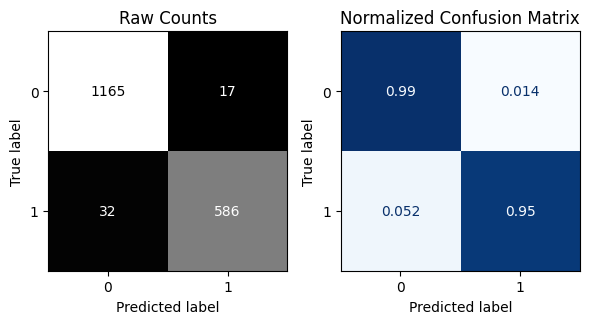


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       397
           1       0.84      0.76      0.80       204

    accuracy                           0.87       601
   macro avg       0.86      0.85      0.85       601
weighted avg       0.87      0.87      0.87       601



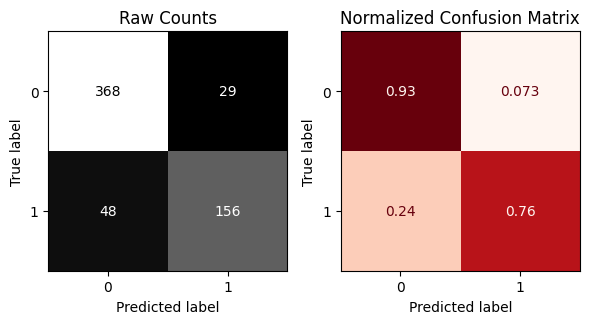

In [48]:
evaluate_classification(best_model, X_train_tf, y_train, X_test_tf, y_test)

## We can see maybe there is overfitting, we will try another model, Logistic regression

In [49]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train_tf, y_train)


LogisticRegression()

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      1182
           1       0.82      0.74      0.78       618

    accuracy                           0.86      1800
   macro avg       0.85      0.83      0.84      1800
weighted avg       0.85      0.86      0.85      1800



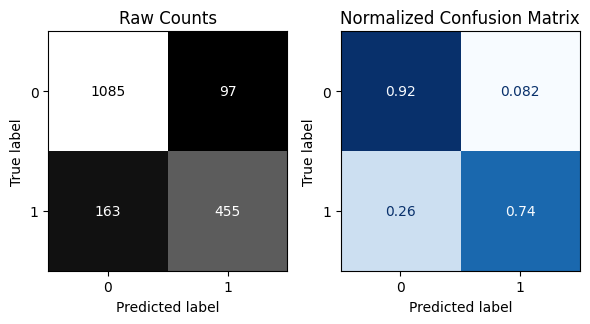


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.91      0.88       397
           1       0.80      0.67      0.73       204

    accuracy                           0.83       601
   macro avg       0.82      0.79      0.80       601
weighted avg       0.83      0.83      0.82       601



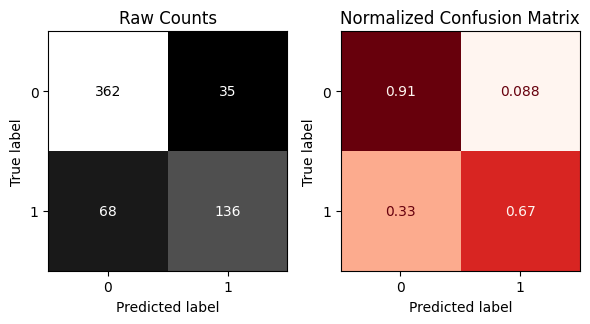

In [50]:
evaluate_classification(log_model, X_train_tf, y_train, X_test_tf, y_test)

## logistic regression give more trusted evaluation, we will try to improve the model by tuning hyperparameters with gridsearch

In [51]:
log_model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [52]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [100,250,400]
}

In [53]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

In [54]:
grid_search.fit(X_train_tf,y_train)

Fitting 3 folds for each of 120 candidates, totalling 360 fits


GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'max_iter': [100, 250, 400], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='recall', verbose=2)

In [55]:
best_model_2 = grid_search.best_estimator_

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1182
           1       0.66      0.86      0.74       618

    accuracy                           0.80      1800
   macro avg       0.78      0.81      0.79      1800
weighted avg       0.83      0.80      0.80      1800



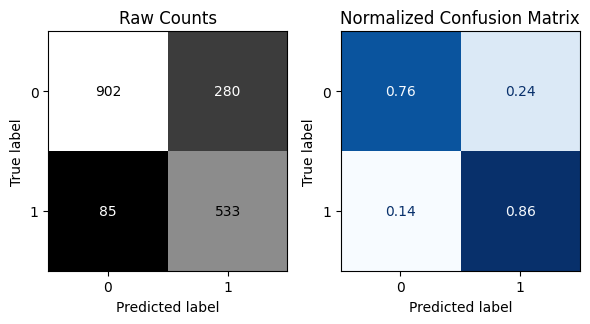


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.76      0.82       397
           1       0.64      0.82      0.72       204

    accuracy                           0.78       601
   macro avg       0.77      0.79      0.77       601
weighted avg       0.81      0.78      0.79       601



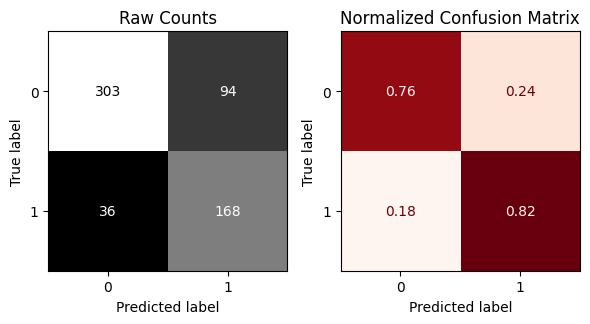

In [56]:
evaluate_classification(best_model_2, X_train_tf, y_train, X_test_tf, y_test)

## as shown, the logistic regression model with tuned hyperparameters is the best, we might can increase the f1-score of the model, but in our case, we assumed that we will focus on recall.

### to show how the model will act if we focus on both precision and recall, we will tune it by focusing on f1 as shown :

In [57]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [58]:
grid_search.fit(X_train_tf,y_train)

Fitting 3 folds for each of 120 candidates, totalling 360 fits


GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'max_iter': [100, 250, 400], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='f1', verbose=2)

In [59]:
best_model_3 = grid_search.best_estimator_

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1182
           1       0.73      0.84      0.78       618

    accuracy                           0.84      1800
   macro avg       0.82      0.84      0.82      1800
weighted avg       0.85      0.84      0.84      1800



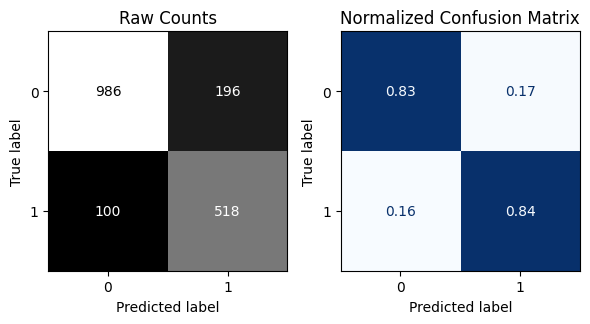


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       397
           1       0.72      0.80      0.76       204

    accuracy                           0.83       601
   macro avg       0.80      0.82      0.81       601
weighted avg       0.83      0.83      0.83       601



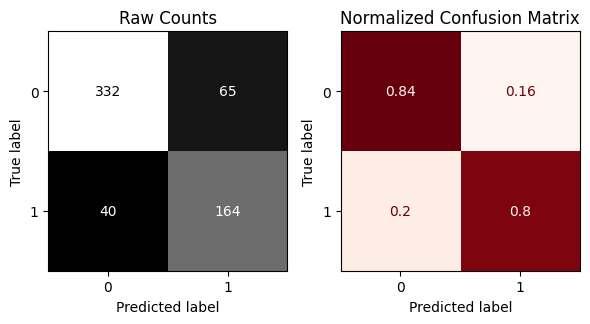

In [60]:
evaluate_classification(best_model_3, X_train_tf, y_train, X_test_tf, y_test)

## Importance

We will discover the important featuresin our model

In [61]:
def get_importances(model, feature_names=None,name='Feature Importance',
                   sort=False, ascending=True):

    ## checking for feature names
    if feature_names == None:
        feature_names = model.feature_names_in_

    ## Saving the feature importances
    importances = pd.Series(model.feature_importances_, index= feature_names,
                           name=name)

    # sort importances
    if sort == True:
        importances = importances.sort_values(ascending=ascending)

    return importances

def plot_importance(importances, top_n=None,  figsize=(8,6)):
    # sorting with asc=false for correct order of bars
    if top_n==None:
        ## sort all features and set title
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        ## sort features and keep top_n and set title
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"
    ## plotting top N importances
    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Importance',
            ylabel='Feature Names',
            title=title)
    ## return ax in case want to continue to update/modify figure
    return ax

In [62]:
def get_color_dict(importances, color_rest='#006ba4' , color_top='green',
                    top_n=7):
    ## color -coding top 5 bars
    highlight_feats = importances.sort_values(ascending=True).tail(top_n).index
    colors_dict = {col: color_top if col in highlight_feats else color_rest for col in importances.index}
    return colors_dict


def plot_importance_color(importances, top_n=None,  figsize=(8,6),
                          color_dict=None):

    # sorting with asc=false for correct order of bars
    if top_n==None:
        ## sort all features and set title
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        ## sort features and keep top_n and set title
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"
    ## create plot with colors, if provided
    if color_dict is not None:
        ## Getting color list and saving to plot_kws
        colors = plot_vals.index.map(color_dict)
        ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors)

    else:
        ## create plot without colors, if not provided
        ax = plot_vals.plot(kind='barh', figsize=figsize)

    # set titles and axis labels
    ax.set(xlabel='Importance',
           ylabel='Feature Names',
           title=title)

    ## return ax in case want to continue to update/modify figure
    return ax

## for model 1

In [63]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test_tf,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_best_model = pd.Series(
    result.importances_mean,
    index=X_test_tf.columns
).sort_values(ascending=False)

print(importance_best_model)

BloodGlucose         0.070383
Triglycerides        0.058403
WaistCirc            0.023295
HDL                  0.008652
Sex_Female           0.006822
BMI                  0.005491
Age                  0.005158
UricAcid             0.002496
Sex_Male             0.002496
Marital_Single       0.002496
Race_White           0.002329
UrAlbCr              0.001997
Marital_NA           0.001997
Race_Asian           0.001830
Race_MexAmerican     0.000998
Marital_Widowed      0.000666
Race_Black           0.000499
Race_Hispanic        0.000166
Marital_Separated    0.000166
Race_Other           0.000000
Albuminuria         -0.000832
Marital_Married     -0.001830
Income              -0.002995
Marital_Divorced    -0.003328
dtype: float64


In [64]:
colors_top10= get_color_dict(importance_best_model, top_n=10)
colors_top10

{'BloodGlucose': 'green',
 'Triglycerides': 'green',
 'WaistCirc': 'green',
 'HDL': 'green',
 'Sex_Female': 'green',
 'BMI': 'green',
 'Age': 'green',
 'UricAcid': 'green',
 'Sex_Male': 'green',
 'Marital_Single': 'green',
 'Race_White': '#006ba4',
 'UrAlbCr': '#006ba4',
 'Marital_NA': '#006ba4',
 'Race_Asian': '#006ba4',
 'Race_MexAmerican': '#006ba4',
 'Marital_Widowed': '#006ba4',
 'Race_Black': '#006ba4',
 'Race_Hispanic': '#006ba4',
 'Marital_Separated': '#006ba4',
 'Race_Other': '#006ba4',
 'Albuminuria': '#006ba4',
 'Marital_Married': '#006ba4',
 'Income': '#006ba4',
 'Marital_Divorced': '#006ba4'}

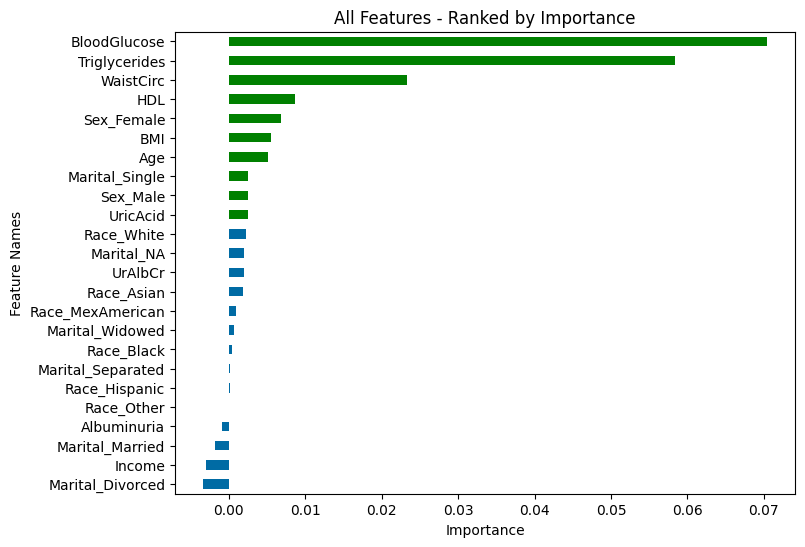

In [65]:
plot_importance_color(importance_best_model, color_dict=colors_top10);

## for model 2

In [66]:
result = permutation_importance(
    best_model_2,
    X_test_tf,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_best_model_2 = pd.Series(
    result.importances_mean,
    index=X_test_tf.columns
).sort_values(ascending=False)

print(importance_best_model_2)

WaistCirc            0.088686
Triglycerides        0.056240
BloodGlucose         0.015474
BMI                  0.000000
UricAcid             0.000000
UrAlbCr              0.000000
Albuminuria          0.000000
Income               0.000000
Marital_Single       0.000000
Marital_Widowed      0.000000
Sex_Female           0.000000
Sex_Male             0.000000
Marital_Divorced     0.000000
Marital_Married      0.000000
Marital_NA           0.000000
Marital_Separated    0.000000
Race_Hispanic        0.000000
Race_MexAmerican     0.000000
Race_Asian           0.000000
Race_Black           0.000000
Race_Other           0.000000
Race_White           0.000000
Age                 -0.001331
HDL                 -0.004326
dtype: float64


In [67]:
colors_top10= get_color_dict(importance_best_model_2, top_n=10)
colors_top10

{'WaistCirc': 'green',
 'Triglycerides': 'green',
 'BloodGlucose': 'green',
 'BMI': '#006ba4',
 'UricAcid': '#006ba4',
 'UrAlbCr': '#006ba4',
 'Albuminuria': '#006ba4',
 'Income': '#006ba4',
 'Marital_Single': 'green',
 'Marital_Widowed': 'green',
 'Sex_Female': '#006ba4',
 'Sex_Male': '#006ba4',
 'Marital_Divorced': '#006ba4',
 'Marital_Married': '#006ba4',
 'Marital_NA': '#006ba4',
 'Marital_Separated': '#006ba4',
 'Race_Hispanic': '#006ba4',
 'Race_MexAmerican': 'green',
 'Race_Asian': 'green',
 'Race_Black': 'green',
 'Race_Other': 'green',
 'Race_White': 'green',
 'Age': '#006ba4',
 'HDL': '#006ba4'}

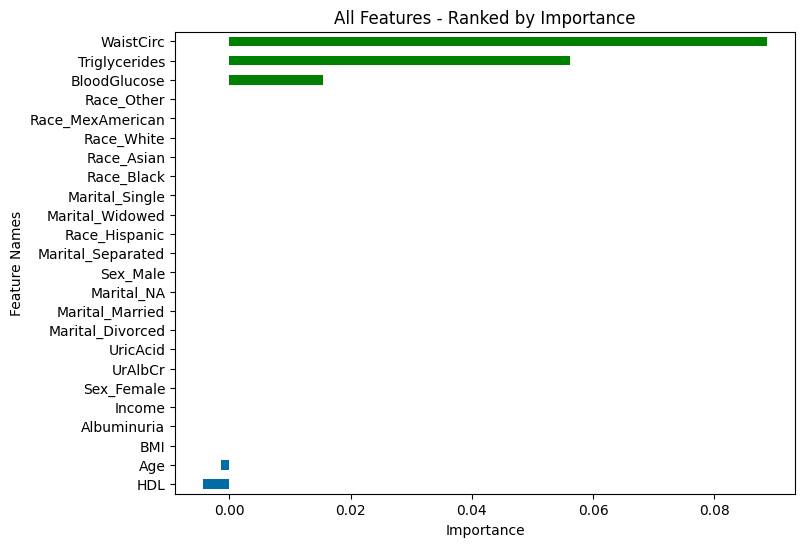

In [68]:
plot_importance_color(importance_best_model_2, color_dict=colors_top10);

## for model 3

In [69]:
result = permutation_importance(
    best_model_3,
    X_test_tf,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_best_model_3 = pd.Series(
    result.importances_mean,
    index=X_test_tf.columns
).sort_values(ascending=False)

print(importance_best_model_3)

Triglycerides        0.073710
WaistCirc            0.064060
BloodGlucose         0.027454
Sex_Male             0.026955
HDL                  0.025957
Age                  0.023794
Sex_Female           0.004493
Marital_Widowed      0.003827
Race_White           0.002662
Marital_Separated    0.001997
Marital_Single       0.001830
Albuminuria          0.000499
Income               0.000333
Race_Black           0.000000
BMI                  0.000000
UrAlbCr              0.000000
Race_Other           0.000000
Marital_Married      0.000000
Marital_Divorced     0.000000
Race_Asian           0.000000
Race_Hispanic       -0.000166
Marital_NA          -0.000499
Race_MexAmerican    -0.000666
UricAcid            -0.003161
dtype: float64


In [70]:
colors_top10= get_color_dict(importance_best_model_3, top_n=10)
colors_top10

{'Triglycerides': 'green',
 'WaistCirc': 'green',
 'BloodGlucose': 'green',
 'Sex_Male': 'green',
 'HDL': 'green',
 'Age': 'green',
 'Sex_Female': 'green',
 'Marital_Widowed': 'green',
 'Race_White': 'green',
 'Marital_Separated': 'green',
 'Marital_Single': '#006ba4',
 'Albuminuria': '#006ba4',
 'Income': '#006ba4',
 'Race_Black': '#006ba4',
 'BMI': '#006ba4',
 'UrAlbCr': '#006ba4',
 'Race_Other': '#006ba4',
 'Marital_Married': '#006ba4',
 'Marital_Divorced': '#006ba4',
 'Race_Asian': '#006ba4',
 'Race_Hispanic': '#006ba4',
 'Marital_NA': '#006ba4',
 'Race_MexAmerican': '#006ba4',
 'UricAcid': '#006ba4'}

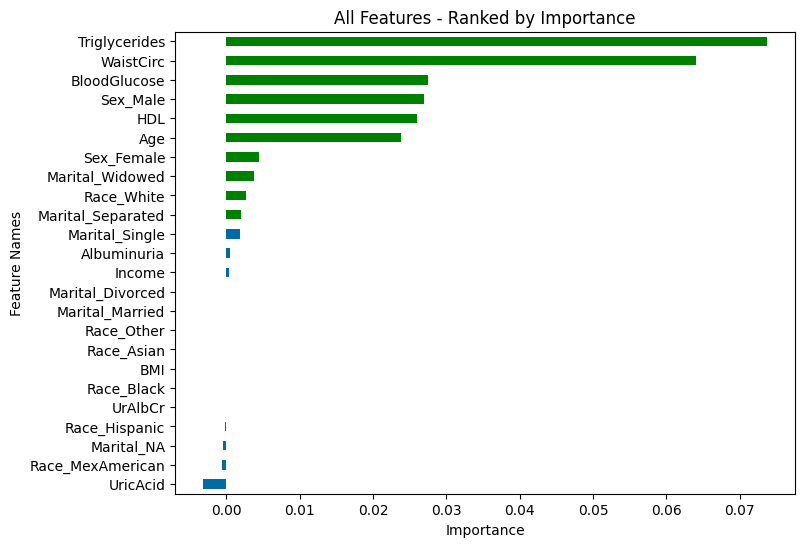

In [71]:
plot_importance_color(importance_best_model_3, color_dict=colors_top10);

### Observation for Model 1

The model identifies Blood Glucose, Triglycerides, Waist Circumference, and HDL cholesterol as the most important predictors. These variables are well-known clinical indicators of metabolic syndrome and are commonly used in medical guidelines to assess metabolic risk. Their prominence suggests that the model captures meaningful metabolic patterns related to the condition, while most demographic variables appear to have limited influence.


### Observation for Model 2

In this model, Waist Circumference, Triglycerides, and Blood Glucose dominate the feature importance ranking. This indicates that the model focuses mainly on the core metabolic measurements associated with central obesity and lipid abnormalities, which are key diagnostic components of metabolic syndrome. Other variables contribute very little to the prediction.


### Observation for Model 3

The model highlights Triglycerides, Waist Circumference, Blood Glucose, HDL, and Age as important predictors. These features are strongly supported by medical knowledge, as lipid levels, glucose regulation, and abdominal obesity are central factors in metabolic syndrome risk, while age is also associated with increased prevalence of the condition.


### Comparison Observation (Between the Three Models)

Across the three models, Triglycerides, Waist Circumference, and Blood Glucose consistently appear among the most important predictors, indicating that metabolic indicators play the dominant role in identifying metabolic syndrome. The main difference between the models lies in the ranking of these features and the contribution of secondary variables, while demographic variables generally show minimal importance compared with the core metabolic measurements.

## Visualizing 2 of the top important features

/tmp/ipykernel_427/1317631937.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = temp.groupby(f'{feature}_bin')['MetabolicSyndrome_numeric'].mean().reset_index()


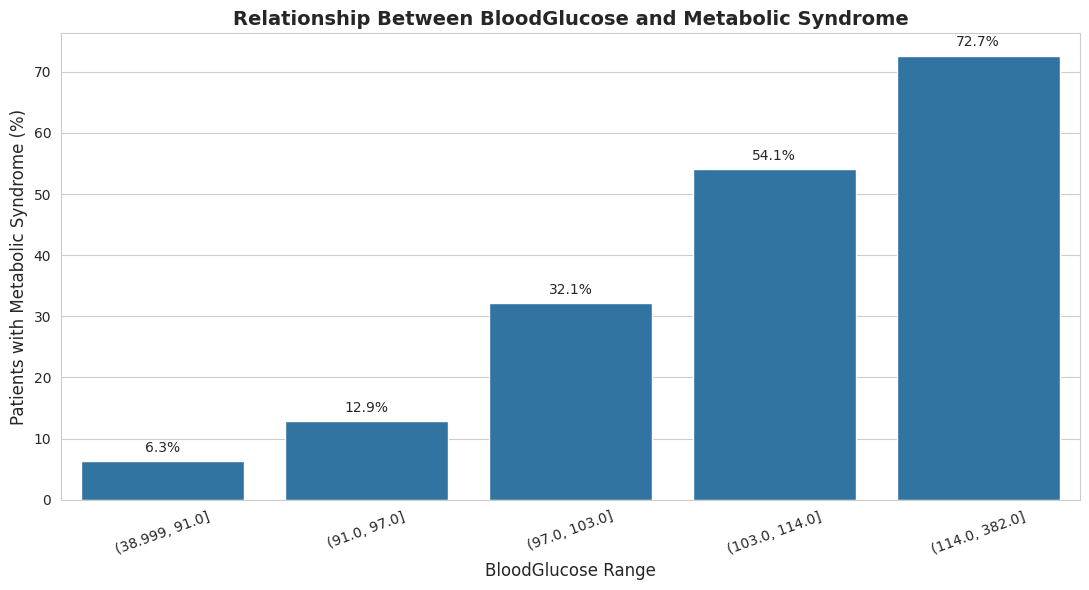

/tmp/ipykernel_427/1317631937.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = temp.groupby(f'{feature}_bin')['MetabolicSyndrome_numeric'].mean().reset_index()


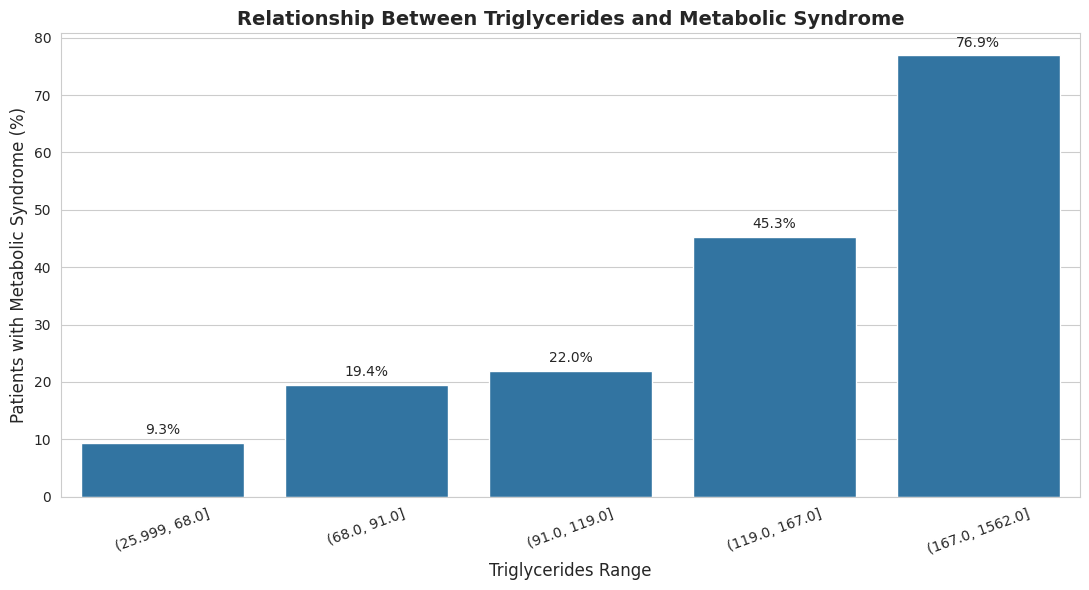

In [72]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Make a copy
viz_df = df.copy()

# Select the 2 top features from permutation importance
top_features = ['BloodGlucose', 'Triglycerides']
target = 'MetabolicSyndrome'

# Map 'MetabolicSyndrome' to numerical values for mean calculation
viz_df['MetabolicSyndrome_numeric'] = viz_df[target].map({'No MetSyn': 0, 'MetSyn': 1})

for feature in top_features:
    # Use the numerical target for calculation
    temp = viz_df[[feature, 'MetabolicSyndrome_numeric']].copy()

    # Create quantile-based bins
    temp[f'{feature}_bin'] = pd.qcut(temp[feature], q=5, duplicates='drop')

    # Calculate metabolic syndrome rate in each bin using the numeric column
    summary = temp.groupby(f'{feature}_bin')['MetabolicSyndrome_numeric'].mean().reset_index()
    summary['bin_label'] = summary[f'{feature}_bin'].astype(str)
    summary['MetS_Rate'] = summary['MetabolicSyndrome_numeric'] * 100  # convert to percentage

    # Plot
    plt.figure(figsize=(11,6))
    ax = sns.barplot(data=summary, x='bin_label', y='MetS_Rate')

    plt.title(f'Relationship Between {feature} and Metabolic Syndrome', fontsize=14, weight='bold')
    plt.xlabel(f'{feature} Range', fontsize=12)
    plt.ylabel('Patients with Metabolic Syndrome (%)', fontsize=12)
    plt.xticks(rotation=20)

    # Add labels on top of bars
    for i, rate in enumerate(summary['MetS_Rate']):
      ax.text(i, rate + 1, f"{rate:.1f}%",
             ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

## Visualization 1: Blood Glucose vs Metabolic Syndrome

- This chart shows that the percentage of patients with metabolic syndrome increases as blood glucose levels rise. This suggests that higher blood glucose is strongly associated with a greater likelihood of metabolic syndrome, which is consistent with the clinical understanding that abnormal glucose regulation is a major warning sign.



## Visualization 2: Triglycerides vs Metabolic Syndrome

- This chart shows that patients in higher triglyceride ranges are more likely to have metabolic syndrome. The upward trend indicates that triglycerides are an important risk-related marker, making this feature highly relevant for identifying patients with elevated metabolic risk.

## PCA

we will find 3 pca that will demonstrate a percentage of variance for the data

In [73]:
from sklearn.decomposition import PCA
# Instantiate PCA to make 3 principal components
pca = PCA(n_components=3)
# Create and define the principal components
X_train_pca = pca.fit_transform(X_train_tf)
X_test_pca = pca.transform(X_test_tf)
# Preview the results
X_train_pca.head()

,pca0,pca1,pca2
seqn,,,
63211,1.319839,-1.157142,-1.251154
70548,-1.519720,0.336563,-0.195937
64722,-1.904998,-0.145949,0.613586
69237,-0.817140,-0.618494,-0.676722
65286,-0.724204,-0.278186,2.697996


In [74]:
# Variance explained by each PC
percentage = pca.explained_variance_ratio_
percentage

array([0.22994912, 0.13277239, 0.10212202])

In [75]:
percentage.sum()

np.float64(0.4648435315800234)

### the 3 pca explain 46.4% of the variance of the data

In [76]:
# Concatenate with original features
X_train_combined = pd.concat([X_train_tf, X_train_pca], axis=1)
X_test_combined = pd.concat([X_test_tf, X_test_pca], axis=1)

# Preview
X_train_combined.head()

,Age,Income,WaistCirc,BMI,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,Albuminuria,Sex_Female,Sex_Male,Marital_Divorced,Marital_Married,Marital_NA,Marital_Separated,Marital_Single,Marital_Widowed,Race_Asian,Race_Black,Race_Hispanic,Race_MexAmerican,Race_Other,Race_White,pca0,pca1,pca2
seqn,,,,,,,,,,,,,,,,,,,,,,,,,,,
63211,-0.176875,1.443579,1.591313,1.815754,-0.100646,-1.503810,0.962189,-0.045041,0.728110,-0.366397,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.319839,-1.157142,-1.251154
70548,-0.857407,-0.165173,-0.767163,-0.637064,-0.108892,0.406271,0.185052,1.929154,-0.704544,-0.366397,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.519720,0.336563,-0.195937
64722,-0.914117,-0.165173,-1.465971,-0.561824,-0.125171,-1.435593,-0.323077,-0.637299,-0.704544,-0.366397,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.904998,-0.145949,0.613586
69237,-0.006742,1.717409,-0.174425,0.687157,-0.152526,-1.913113,-0.562196,-0.176654,0.115599,-0.366397,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.817140,-0.618494,-0.676722
65286,-1.084250,1.717409,-1.422296,-1.028311,-0.138548,1.088443,-0.801315,0.283992,2.762893,-0.366397,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.724204,-0.278186,2.697996


# for model 1

In [77]:
best_model.fit(X_train_combined, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=10)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1182
           1       0.96      0.95      0.96       618

    accuracy                           0.97      1800
   macro avg       0.97      0.97      0.97      1800
weighted avg       0.97      0.97      0.97      1800



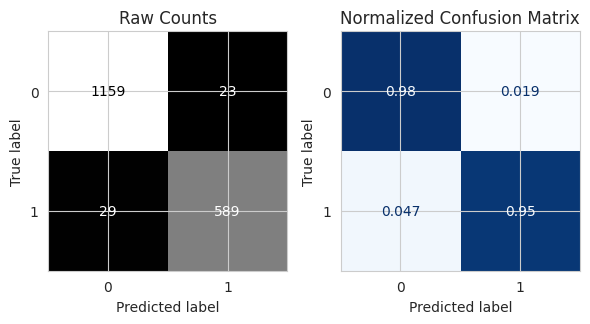


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       397
           1       0.83      0.78      0.81       204

    accuracy                           0.87       601
   macro avg       0.86      0.85      0.85       601
weighted avg       0.87      0.87      0.87       601



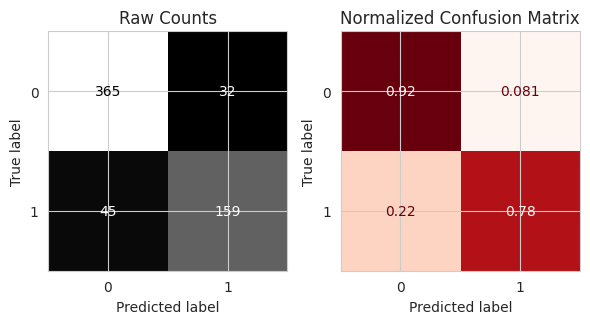

In [78]:
evaluate_classification(best_model, X_train_combined, y_train, X_test_combined, y_test)

# for model 2

In [79]:
best_model_2.fit(X_train_combined, y_train)

LogisticRegression(C=0.01, class_weight='balanced', penalty='l1',
                   solver='liblinear')

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1182
           1       0.63      0.85      0.72       618

    accuracy                           0.78      1800
   macro avg       0.77      0.79      0.77      1800
weighted avg       0.81      0.78      0.78      1800



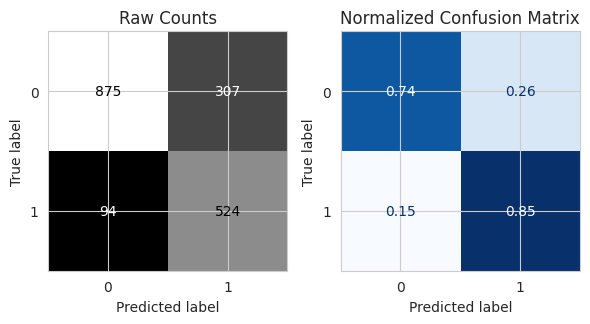


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.75      0.81       397
           1       0.62      0.82      0.71       204

    accuracy                           0.77       601
   macro avg       0.76      0.78      0.76       601
weighted avg       0.80      0.77      0.78       601



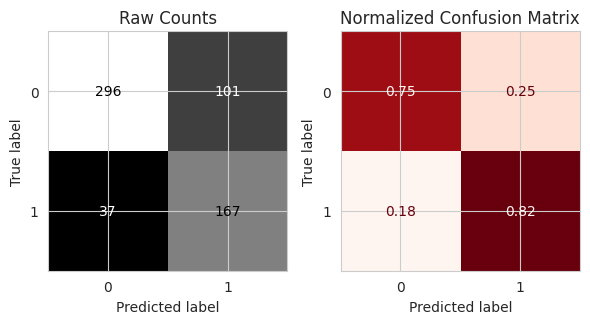

In [80]:
evaluate_classification(best_model_2, X_train_combined, y_train, X_test_combined, y_test)

# for model 3

In [81]:
best_model_3.fit(X_train_combined, y_train)

LogisticRegression(C=1, class_weight='balanced', penalty='l1',
                   solver='liblinear')

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1182
           1       0.73      0.84      0.78       618

    accuracy                           0.84      1800
   macro avg       0.82      0.84      0.82      1800
weighted avg       0.85      0.84      0.84      1800



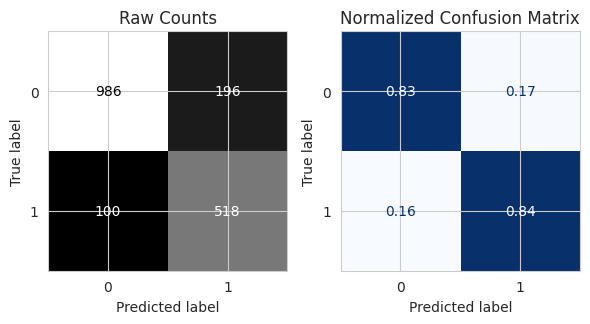


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       397
           1       0.72      0.80      0.76       204

    accuracy                           0.83       601
   macro avg       0.80      0.82      0.81       601
weighted avg       0.83      0.83      0.83       601



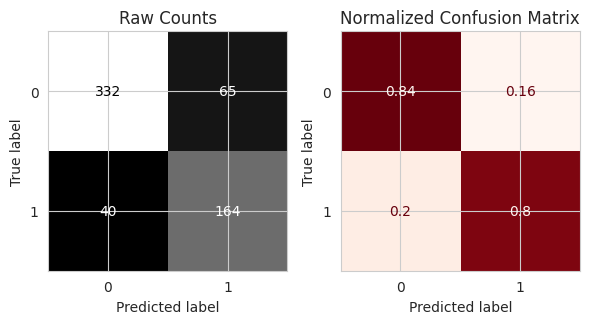

In [82]:
evaluate_classification(best_model_3, X_train_combined, y_train, X_test_combined, y_test)

## Comparison

- Adding the PCA components did not improve model performance. The confusion matrices for both the training and test sets remained almost the same for all models, before and after adding PCA features. This suggests that the original features already captured the relevant predictive information, and the added PCA components did not provide meaningful additional value to the model.

## lets try to replace feature of model 1 with pca that exlain 70% of the feature, this new data set might decrease the overfitting

In [83]:
# Instantiate PCA
pca = PCA()
pca.fit(X_train_tf, y_train)

PCA()

In [84]:
# Determine how much variance is explained by each PC
explained = pd.Series(pca.explained_variance_ratio_, name='Explained Variance Ratio')
explained


,Explained Variance Ratio
0,2.299491e-01
1,1.327724e-01
2,1.021220e-01
3,9.313044e-02
4,8.743165e-02
5,7.189079e-02
6,5.865233e-02
7,4.568779e-02
8,3.800900e-02
9,2.712874e-02


In [85]:
# Define PCA to address 85% of the variance
pca70 = PCA(n_components=.7)
# fit and transform on training data
X_train_pca70 = pca70.fit_transform(X_train_tf)
# transform test data
X_test_pca70 = pca70.transform(X_test_tf)
# obtain the number of PCs used
pca70.n_components_

np.int64(6)

### so 6 components can explain 70% of the variance of the data

In [86]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [87]:

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_pca70, y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=2)

In [88]:
best_model_new = grid_search.best_estimator_

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1182
           1       1.00      0.99      0.99       618

    accuracy                           0.99      1800
   macro avg       1.00      0.99      0.99      1800
weighted avg       1.00      0.99      0.99      1800



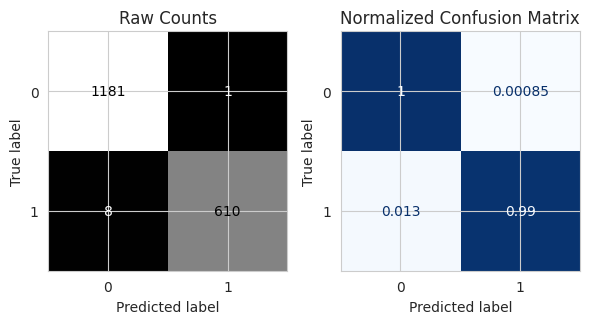


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       397
           1       0.71      0.71      0.71       204

    accuracy                           0.80       601
   macro avg       0.78      0.78      0.78       601
weighted avg       0.80      0.80      0.80       601



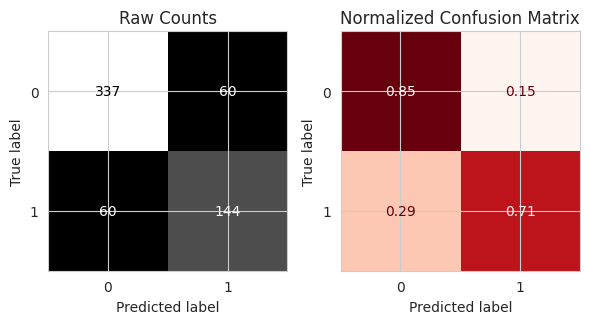

In [89]:
evaluate_classification(best_model_new, X_train_pca70, y_train, X_test_pca70, y_test)

The results indicate that the overfitting has been slightly reduced. However, the overall performance is still not optimal. Nevertheless, this step was part of the process of attempting to identify the best possible model.

### Adding the PCA components did not improve model performance

## feature selection

# for model 1

In [90]:
from sklearn.feature_selection import SequentialFeatureSelector
import time

start = time.perf_counter()

sfs = SequentialFeatureSelector(
    best_model,
    n_features_to_select='auto',
    direction='forward',
    scoring='recall',
    cv=3,
    n_jobs=-1
)

sfs.fit(X_train_combined, y_train)

# Selected feature names
selected_features = X_train_combined.columns[sfs.get_support()]
print("Selected features:")
print(selected_features)

# Keep only selected features
X_train_selected = X_train_combined.loc[:, selected_features]
X_test_selected = X_test_combined.loc[:, selected_features]

# =========================
# 3) Train final model
# =========================
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_selected, y_train)


end = time.perf_counter()

print("Runtime:", end - start)

Selected features:
Index(['WaistCirc', 'BMI', 'BloodGlucose', 'Triglycerides', 'Albuminuria',
       'Sex_Female', 'Sex_Male', 'Marital_Married', 'Marital_NA',
       'Marital_Separated', 'Race_Hispanic', 'Race_MexAmerican', 'pca0'],
      dtype='object')
Runtime: 210.63754266700005


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1182
           1       0.80      0.70      0.75       618

    accuracy                           0.84      1800
   macro avg       0.83      0.80      0.81      1800
weighted avg       0.84      0.84      0.83      1800



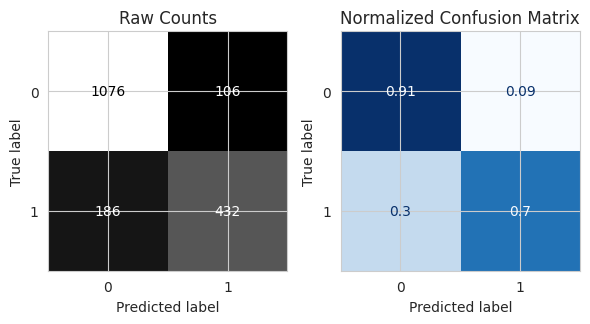


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       397
           1       0.76      0.67      0.71       204

    accuracy                           0.82       601
   macro avg       0.80      0.78      0.79       601
weighted avg       0.81      0.82      0.81       601



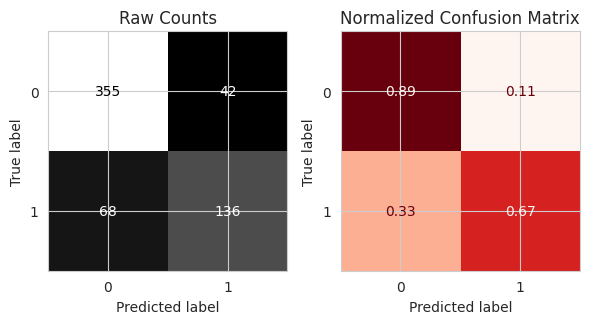

In [91]:
evaluate_classification(final_model , X_train_selected, y_train, X_test_selected, y_test)

In [92]:
result = permutation_importance(
    final_model,
    X_test_selected,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(
    result.importances_mean,
    index=X_test_selected.columns
).sort_values(ascending=False)


In [93]:
colors_top10= get_color_dict(importance, top_n=10)
colors_top10

{'pca0': 'green',
 'Triglycerides': 'green',
 'BloodGlucose': 'green',
 'WaistCirc': 'green',
 'BMI': 'green',
 'Sex_Male': 'green',
 'Sex_Female': 'green',
 'Albuminuria': 'green',
 'Marital_NA': 'green',
 'Marital_Separated': 'green',
 'Race_MexAmerican': '#006ba4',
 'Marital_Married': '#006ba4',
 'Race_Hispanic': '#006ba4'}

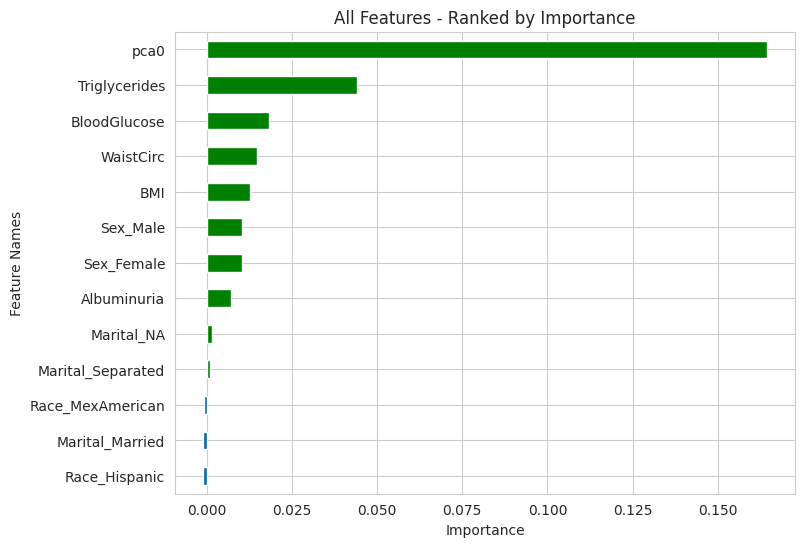

In [94]:
plot_importance_color(importance, color_dict=colors_top10);

## we will continue with model 2

In [95]:
from sklearn.feature_selection import SequentialFeatureSelector


sfs = SequentialFeatureSelector(
    best_model_2,
    n_features_to_select='auto',
    direction='forward',
    scoring='recall',
    cv=5,
    n_jobs=-1
)

sfs.fit(X_train_combined, y_train)

# Selected feature names
selected_features = X_train_combined.columns[sfs.get_support()]
print("Selected features:")
print(selected_features)

# Keep only selected features
X_train_selected = X_train_combined.loc[:, selected_features]
X_test_selected = X_test_combined.loc[:, selected_features]

# =========================
# 3) Train final model
# =========================
final_model_2 = LogisticRegression(max_iter=1000, random_state=42)
final_model_2.fit(X_train_selected, y_train)

Selected features:
Index(['Age', 'Income', 'WaistCirc', 'BMI', 'UrAlbCr', 'UricAcid',
       'BloodGlucose', 'HDL', 'Triglycerides', 'Albuminuria', 'Sex_Female',
       'Sex_Male', 'pca0'],
      dtype='object')


LogisticRegression(max_iter=1000, random_state=42)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1182
           1       0.82      0.72      0.76       618

    accuracy                           0.85      1800
   macro avg       0.84      0.82      0.83      1800
weighted avg       0.85      0.85      0.85      1800



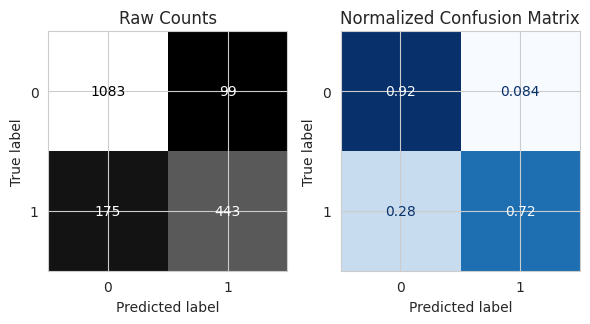


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       397
           1       0.79      0.66      0.72       204

    accuracy                           0.82       601
   macro avg       0.81      0.78      0.79       601
weighted avg       0.82      0.82      0.82       601



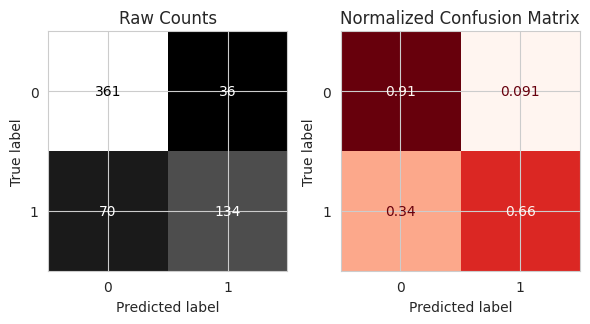

In [96]:
evaluate_classification(final_model_2, X_train_selected, y_train, X_test_selected, y_test)

In [97]:
result = permutation_importance(
    final_model_2,
    X_test_selected,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(
    result.importances_mean,
    index=X_test_selected.columns
).sort_values(ascending=False)

print(importance)

Triglycerides    0.058403
WaistCirc        0.029285
pca0             0.020799
HDL              0.020133
BloodGlucose     0.020133
Sex_Male         0.014143
Age              0.010649
Albuminuria      0.005824
Sex_Female       0.004825
UrAlbCr          0.001830
Income          -0.000666
UricAcid        -0.000666
BMI             -0.003161
dtype: float64


In [98]:
colors_top10= get_color_dict(importance, top_n=10)
colors_top10

{'Triglycerides': 'green',
 'WaistCirc': 'green',
 'pca0': 'green',
 'HDL': 'green',
 'BloodGlucose': 'green',
 'Sex_Male': 'green',
 'Age': 'green',
 'Albuminuria': 'green',
 'Sex_Female': 'green',
 'UrAlbCr': 'green',
 'Income': '#006ba4',
 'UricAcid': '#006ba4',
 'BMI': '#006ba4'}

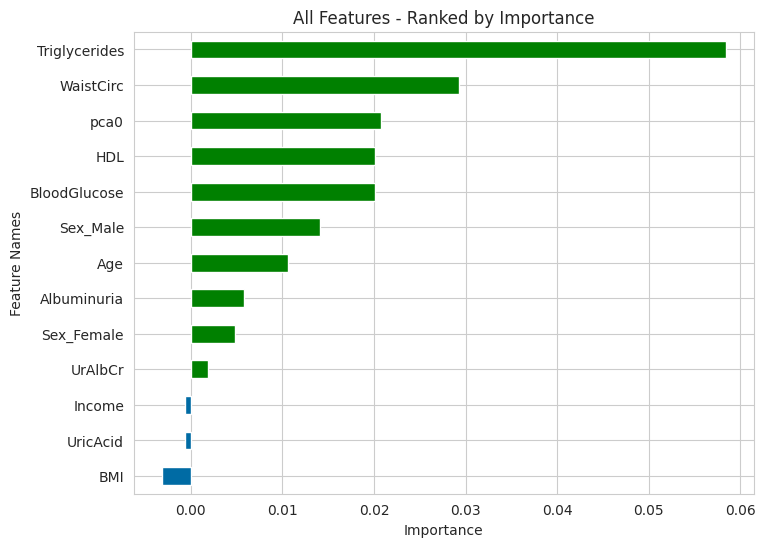

In [99]:
plot_importance_color(importance, color_dict=colors_top10);

### Comparison to Part 1

The most important predictors are largely consistent between the two models. In both cases, the key features remain the main clinical indicators of metabolic syndrome, particularly Triglycerides, WaistCirc, and BloodGlucose, indicating that the core signal in the data is stable.

However, there is a slight change in the ranking of the top features. In the first model, WaistCirc is the most important predictor, while in the second model Triglycerides becomes the top feature.

Another difference is the appearance of the PCA-derived feature (pca0) among the top predictors in the second model, whereas the first model relies only on the original variables.

Overall, both models depend on the same main metabolic predictors, with minor differences in feature ranking and the inclusion of a PCA component in the second model.

# ANN

### as accuracy is wanted to be predict, we will balance the data by smote

In [100]:
# using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_tf, y_train = smote.fit_resample(X_train_tf, y_train)

In [101]:
# Deep learning tols
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [102]:
# Sequential model
model = Sequential()

In [103]:
input_shape = X_train_tf.shape[1]
input_shape

24

In [104]:
model.add(Dense(12,input_dim = X_train_tf.shape[1],activation = 'relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [105]:
# Output layer
model.add(Dense(1, activation = 'sigmoid'))

In [106]:
# Metrics are specified during the .compile step
# Step 2: Compile
model.compile(loss = 'binary_crossentropy', optimizer = 'adam'
              , metrics=[
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.Precision(name='precision'),
                        ])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313 (1.22 KB)

 Trainable params: 313 (1.22 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
# import early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

In [108]:
from sklearn.preprocessing import LabelEncoder


history = model.fit(X_train_tf, y_train,
                     validation_split =.2,
                    epochs=50,
                   callbacks = [early_stopping] )

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7094 - precision: 0.2553 - recall: 0.0169 - val_loss: 0.9688 - val_precision: 1.0000 - val_recall: 0.0761
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5623 - precision: 0.7090 - recall: 0.2440 - val_loss: 0.7526 - val_precision: 1.0000 - val_recall: 0.4482
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4823 - precision: 0.7769 - recall: 0.5303 - val_loss: 0.6515 - val_precision: 1.0000 - val_recall: 0.6427
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4329 - precision: 0.7735 - recall: 0.6841 - val_loss: 0.5827 - val_precision: 1.0000 - val_recall: 0.7082
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4007 - precision: 0.7701 - recall: 0.7278 - val_loss: 0.5278 - val_precision: 1.0000 - val_recall: 0.7526
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3807 - precision: 0.7741 - recall: 0.7588 - val_loss: 0.5091 - val_precision: 1.0000 - val_recall: 0.7590
Epoc

In [109]:
# Convert the history to a dataframe for readability
history_df = pd.DataFrame(history.history)
history_df

,loss,precision,recall,val_loss,val_precision,val_recall
0,0.709388,0.255319,0.016925,0.968765,1.0,0.076110
1,0.562328,0.709016,0.244006,0.752601,1.0,0.448203
2,0.482307,0.776860,0.530324,0.651491,1.0,0.642706
3,0.432853,0.773525,0.684062,0.582651,1.0,0.708245
4,0.400746,0.770149,0.727786,0.527810,1.0,0.752643
5,0.380660,0.774101,0.758815,0.509053,1.0,0.758985
6,0.366326,0.794074,0.755994,0.490563,1.0,0.773784
7,0.355894,0.793605,0.770099,0.463289,1.0,0.792812
8,0.347817,0.805926,0.767278,0.462628,1.0,0.799154
9,0.342128,0.816265,0.764457,0.453456,1.0,0.799154


In [110]:
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)


    # For each metric
    for i, metric_name in enumerate(metrics):
        # Get the axis for the current metric
        if len(metrics)==1:
            ax = axes
        else:
            ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()
    return fig, axes

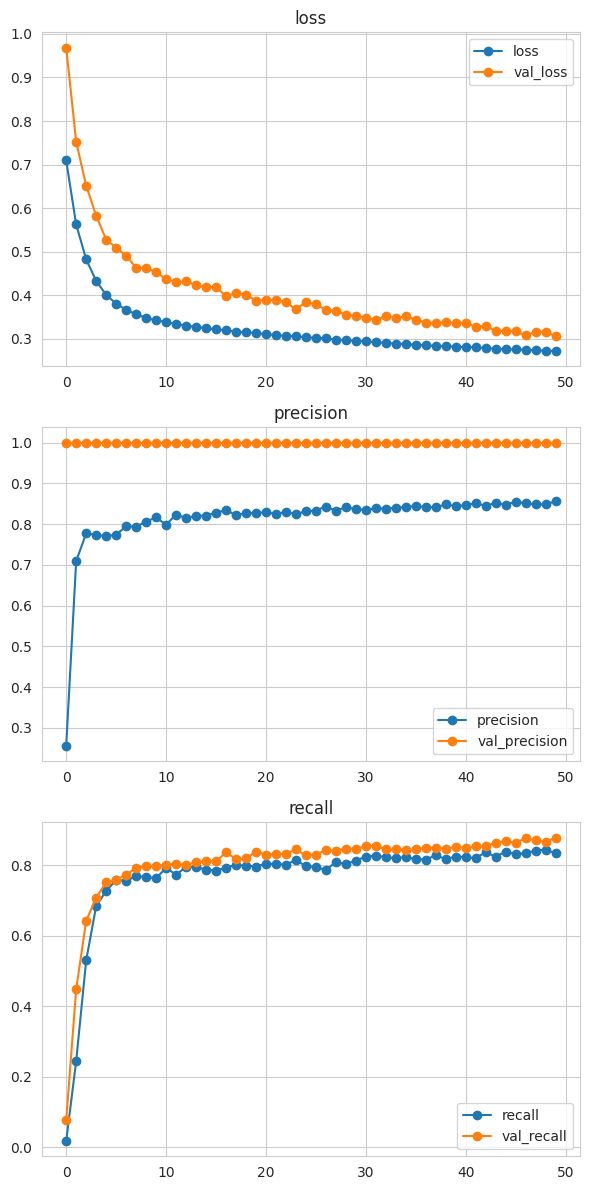

In [111]:
# Call the custom function
plot_history(history);

In [112]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
    report = classification_report(y_true, y_pred)

    header = "-" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=None, cmap='gist_gray',
        colorbar=colorbar, ax=axes[0]
    )
    axes[0].set_title("Raw Counts")

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=normalize, cmap=cmap,
        colorbar=colorbar, ax=axes[1]
    )
    axes[1].set_title("Normalized Confusion Matrix")

    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6,4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test="Reds", colorbar=False,
                            convert_target=False, threshold=0.5):
    if convert_target:
        le = LabelEncoder()
        y_train_encoded = le.fit_transform(y_train)
        y_test_encoded = le.transform(y_test)
    else:
        y_train_encoded = y_train
        y_test_encoded = y_test

    y_train_pred = model.predict(X_train)

    if convert_target:
        y_train_pred = np.array(y_train_pred).ravel()
        if y_train_pred.dtype.kind in ['f', 'c']:
            y_train_pred = (y_train_pred >= threshold).astype(int)
        y_train_pred = le.inverse_transform(y_train_pred)

    results_train = classification_metrics(
        y_train, y_train_pred,
        output_dict=True,
        figsize=figsize,
        colorbar=colorbar,
        cmap=cmap_train,
        normalize=normalize,
        label='Training Data'
    )

    print()

    y_test_pred = model.predict(X_test)

    if convert_target:
        y_test_pred = np.array(y_test_pred).ravel()
        if y_test_pred.dtype.kind in ['f', 'c']:
            y_test_pred = (y_test_pred >= threshold).astype(int)
        y_test_pred = le.inverse_transform(y_test_pred)

    results_test = classification_metrics(
        y_test, y_test_pred,
        output_dict=True,
        figsize=figsize,
        colorbar=colorbar,
        cmap=cmap_test,
        normalize=normalize,
        label='Test Data'
    )

    if output_dict:
        return {
            'train': results_train,
            'test': results_test
        }

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.91      0.89      1182
           1       0.91      0.86      0.88      1182

    accuracy                           0.88      2364
   macro avg       0.89      0.88      0.88      2364
weighted avg       0.89      0.88      0.88      2364



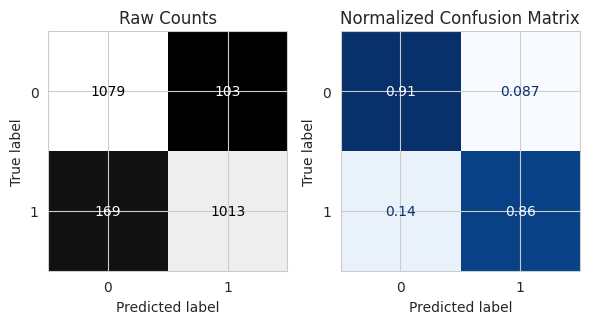


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       397
           1       0.77      0.75      0.76       204

    accuracy                           0.84       601
   macro avg       0.82      0.82      0.82       601
weighted avg       0.84      0.84      0.84       601



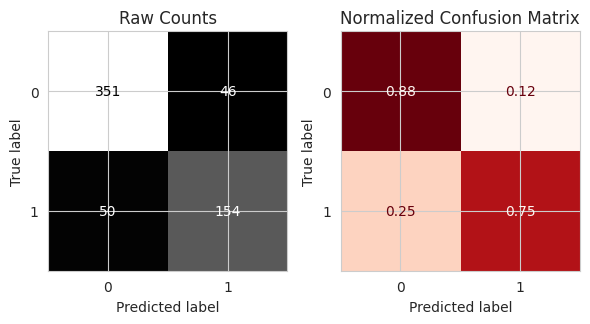

In [113]:
evaluate_classification(model, X_train_tf, y_train, X_test_tf, y_test, convert_target=True)

## Tuning parameters

In [114]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.7 MB/s eta 0:00:00


In [115]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers
from keras_tuner import HyperParameters as hp
import keras_tuner as kt


In [116]:
# Make a folder to store results of hyperparameter tuning
import os
folder = 'KerasTuner/'
os.makedirs(folder, exist_ok=True)

In [117]:
input_shape = X_train_tf.shape[1]
input_shape

24

In [118]:
# Build and Compile Model within a function to try optimizers
def build_model(hp):
  model = Sequential()
  model.add(Dense(24,input_dim = X_train_tf.shape[1], activation=hp.Choice('activation_1', ['relu', 'tanh'])))

  model.add(Dense(
     hp.Int('units', min_value=10, max_value=50, step=5),
     activation=hp.Choice('activation_2', ['relu', 'tanh']),
     kernel_regularizer=regularizers.l1_l2(
         l1=hp.Float('l1', min_value=0.005, max_value=0.05, step=0.005),
         l2=hp.Float('l2', min_value=0.005, max_value=0.05, step=0.005)
    )
 ))
  model.add(Dropout(
     hp.Choice('dropout_rate', values=[0.2, 0.3, 0.4])
 ))

  model.add(Dense(1, activation = 'sigmoid'))

  model.compile(loss = 'binary_crossentropy', optimizer = hp.Choice('optimizer',['rmsprop','nadam','adam']),
                metrics=[
                          'accuracy',
                          tf.keras.metrics.Recall(name='recall'),
                          tf.keras.metrics.Precision(name='precision'),
                        ])

  # Removed model.fit and y_train/y_test one-hot encoding from here as tuner.search handles fitting
  return model

In [119]:
# Define tuner object
tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=5,
                     directory=folder,
                     overwrite = True,
                     seed = 42,
                     project_name='Metabolic Syndrome Prediction')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [120]:
# Run the tuner
tuner.search(X_train_tf, y_train,epochs=150,
             validation_split = 0.2)

Trial 10 Complete [00h 00m 04s]
val_accuracy: 0.7674418687820435

Best val_accuracy So Far: 0.7906976938247681
Total elapsed time: 00h 01m 01s


In [121]:
# Obtain best hyperparameter values
best_hps=tuner.get_best_hyperparameters()[0]
best_hps.values

{'activation_1': 'tanh',
 'units': 20,
 'activation_2': 'relu',
 'l1': 0.015,
 'l2': 0.045,
 'dropout_rate': 0.3,
 'optimizer': 'nadam',
 'tuner/epochs': 2,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 1,
 'tuner/round': 0}

In [122]:
# Obtain best model
best_model = tuner.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 15 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.53      0.61      1182
           1       0.63      0.79      0.70      1182

    accuracy                           0.66      2364
   macro avg       0.67      0.66      0.65      2364
weighted avg       0.67      0.66      0.65      2364



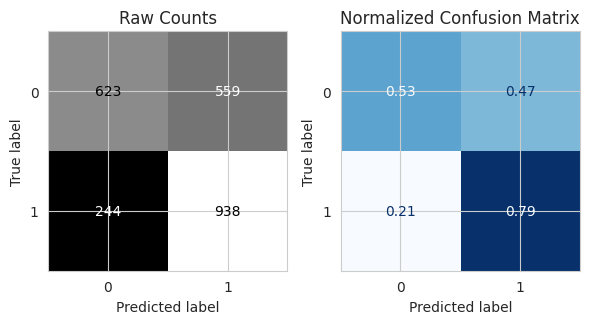


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.52      0.64       397
           1       0.46      0.81      0.59       204

    accuracy                           0.62       601
   macro avg       0.65      0.66      0.61       601
weighted avg       0.71      0.62      0.62       601



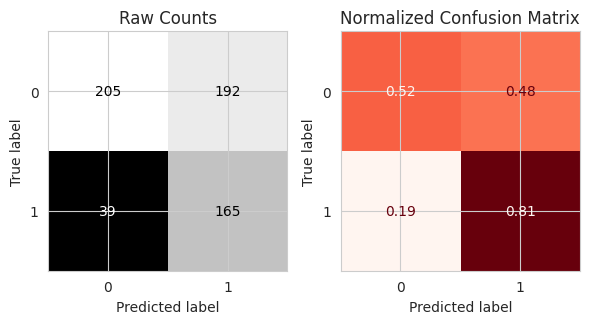

In [123]:
evaluate_classification(best_model, X_train_tf, y_train, X_test_tf, y_test,convert_target=True)

In [124]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

best_model = build_model(best_hp)

history = best_model.fit(
    X_train_tf, y_train,
    validation_data=(X_test_tf, y_test),
    epochs=150,
    verbose=1
)

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6523 - loss: 2.5437 - precision: 0.6438 - recall: 0.6819 - val_accuracy: 0.7604 - val_loss: 2.0383 - val_precision: 0.6230 - val_recall: 0.7451
Epoch 2/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7788 - loss: 1.6939 - precision: 0.7795 - recall: 0.7775 - val_accuracy: 0.7887 - val_loss: 1.3723 - val_precision: 0.6584 - val_recall: 0.7843
Epoch 3/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8054 - loss: 1.1564 - precision: 0.8008 - recall: 0.8130 - val_accuracy: 0.7887 - val_loss: 0.9710 - val_precision: 0.6498 - val_recall: 0.8186
Epoch 4/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8177 - loss: 0.8308 - precision: 0.8011 - recall: 0.8452 - val_accuracy: 0.8037 - val_loss: 0.7221 - val_precision: 0.6762 - val_recall: 0.8088
Epoch 5/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8266 - loss: 0.6461 - precision: 0.8108 - recall: 0.8519 - val_accuracy: 0.8103 - val_loss: 0.5906 - val_pr

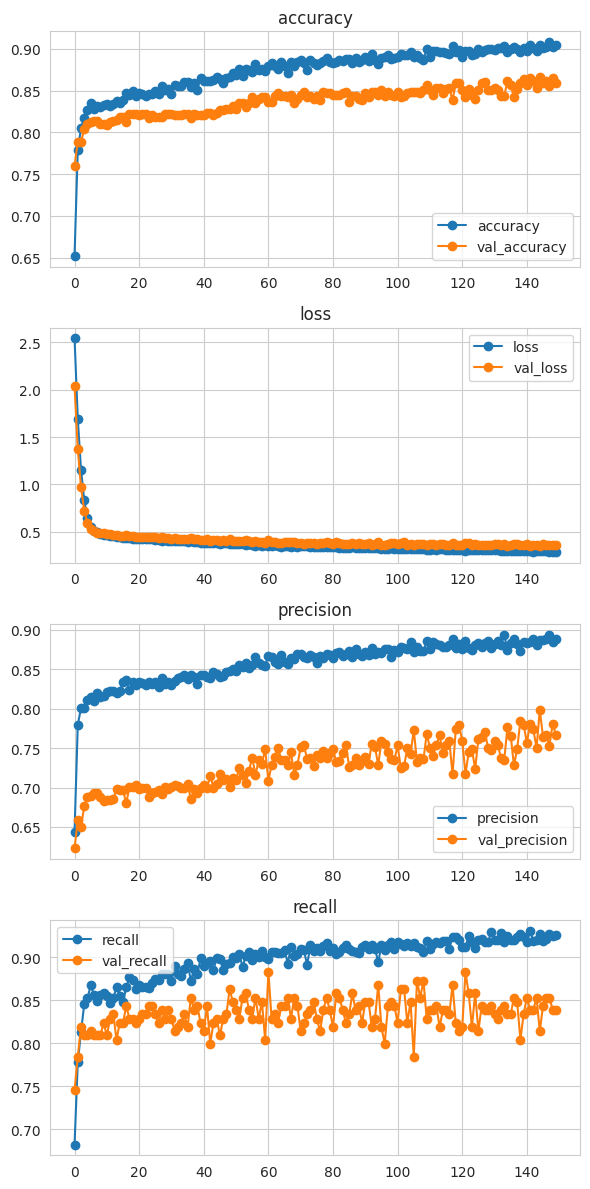

In [125]:
plot_history(history);